In [1]:
import torch
import torchvision
from src.vmmdref.VMMDDiagonal1Channel import VMMDDiagonal1Channel
from torch import nn
from torchvision.transforms import transforms

from src.models.autoencoder.resnet.ResNet18AutoEncoder import ResNet18AutoEncoder
from src.models.autoencoder.resnet.ResNet50AutoEncoder import ResNet50AutoEncoder
from src.models.generator.convolution.GeneratorConvLinearMappingBigSigmV2 import GeneratorConvLinearMappingBigSigmV2
from src.vmmdref.VMMDConvLinearMappingRef import VMMDConvLinearMappingRef

In [2]:
import numpy as np
from sklearn.model_selection import ParameterSampler

def generate_hyperparams(n_iter=10, random_state=777):
    """
    Generates a list of dictionaries, each containing a random combination
    of hyperparameters for model tuning.

    :param n_iter:        How many random hyperparameter sets to generate.
    :param random_state:  Seed for reproducibility.
    :return:              A list of dictionaries with hyperparameter configurations.
    """

    # Define your hyperparameter search space
    param_distributions = {
        'batch_size':    [128, 256, 500, 1024],
        'epochs':        [1000, 500, 700, 400],
        'lr':            [0.5, 0.1, 0.05, 0.01, 0.005] ,    # e.g., [1e-4, 1e-3, 1e-2, 1e-1]
        'momentum':      np.linspace(0.8, 0.99, 5),  # e.g., [0.8, 0.85, 0.9, 0.95, 0.99]
        'seed':          [777, 111, 222, 333],
        'weight_decay':  np.logspace(-4, -1, 4), # e.g., [1e-4, 1e-3, 1e-2, 1e-1]
        'latent_size': [64, 256, 512, 1024]
    }

    # Randomly sample n_iter configurations from the above distributions
    sampler = ParameterSampler(param_distributions, n_iter=n_iter, random_state=random_state)

    # Convert the iterator to a list of dictionaries
    param_list = list(sampler)
    return param_list

In [3]:
transform = transforms.Compose(
    [
        transforms.ToTensor(),
 #       transforms.Normalize(mean=[0.4955, 0.4564, 0.4155], std=[0.2568, 0.2523, 0.2580])
     ]
)
dataset = torchvision.datasets.CIFAR10(root='../../data', train=True, download=True,
                                       transform=transform)
cats_dataset = [(img, label) for (img, label) in dataset if label == 3]

Files already downloaded and verified


In [1]:
from src.models.generator.linear_mapping.GeneratorLinearMappingTanh import GeneratorLinearMappingTanh
from src.vmmdref.VMMDLinearMappingRef import VMMDLinearMappingRef

hyperparameter_list = generate_hyperparams(n_iter=10, random_state=777)
for i in range(1, len(hyperparameter_list)):
    vmmd =VMMDLinearMappingRef(
        filename=f"linear_mapping_hypparam_1_{i}",
        weight_decay=hyperparameter_list[i]['weight_decay'],
        seed=hyperparameter_list[i]['seed'],
        momentum=hyperparameter_list[i]['momentum'],
        lr=0.5,
        epochs=100,
        batch_size=hyperparameter_list[i]['batch_size'],
        path_to_directory="")
    noise_dim = 256
    vmmd.fit(cats_dataset, ResNet18AutoEncoder(), GeneratorLinearMappingTanh(noise_dim))

NameError: name 'generate_hyperparams' is not defined

In [1]:
from src.models.generator.linear_mapping.GeneratorLinearMappingTanh import GeneratorLinearMappingTanh
from src.vmmdref.VMMDLinearMappingRef import VMMDLinearMappingRef

hyperparameter_list = generate_hyperparams(n_iter=9, random_state=777)
for i in range(1, len(hyperparameter_list)):
    vmmd =VMMDLinearMappingRef(
        filename=f"linear_mapping_hypparam_1_{i}",
        weight_decay=hyperparameter_list[i]['weight_decay'],
        seed=hyperparameter_list[i]['seed'],
        momentum=hyperparameter_list[i]['momentum'],
        lr=hyperparameter_list[i]['lr'],
        epochs=hyperparameter_list[i]['epochs'],
        batch_size=hyperparameter_list[i]['batch_size'],
        path_to_directory="/home/i40/enciup/V-GAN/experiments/remote")
    noise_dim = hyperparameter_list[i]['latent_size']
    vmmd.fit(cats_dataset, ResNet50AutoEncoder(), GeneratorLinearMappingTanh(noise_dim))

NameError: name 'generate_hyperparams' is not defined

Count:  500 PVal:  1.0
The show option has been depricated due to lack of utility


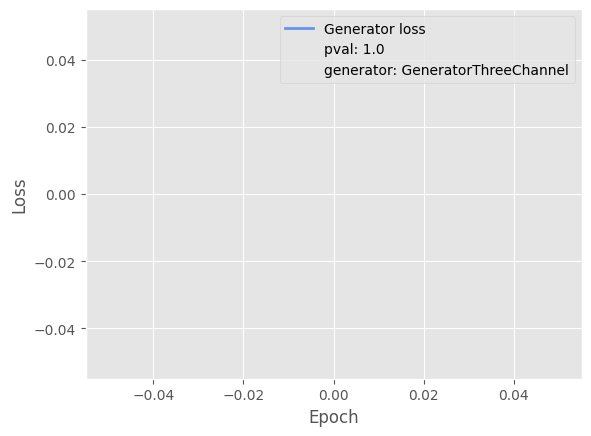

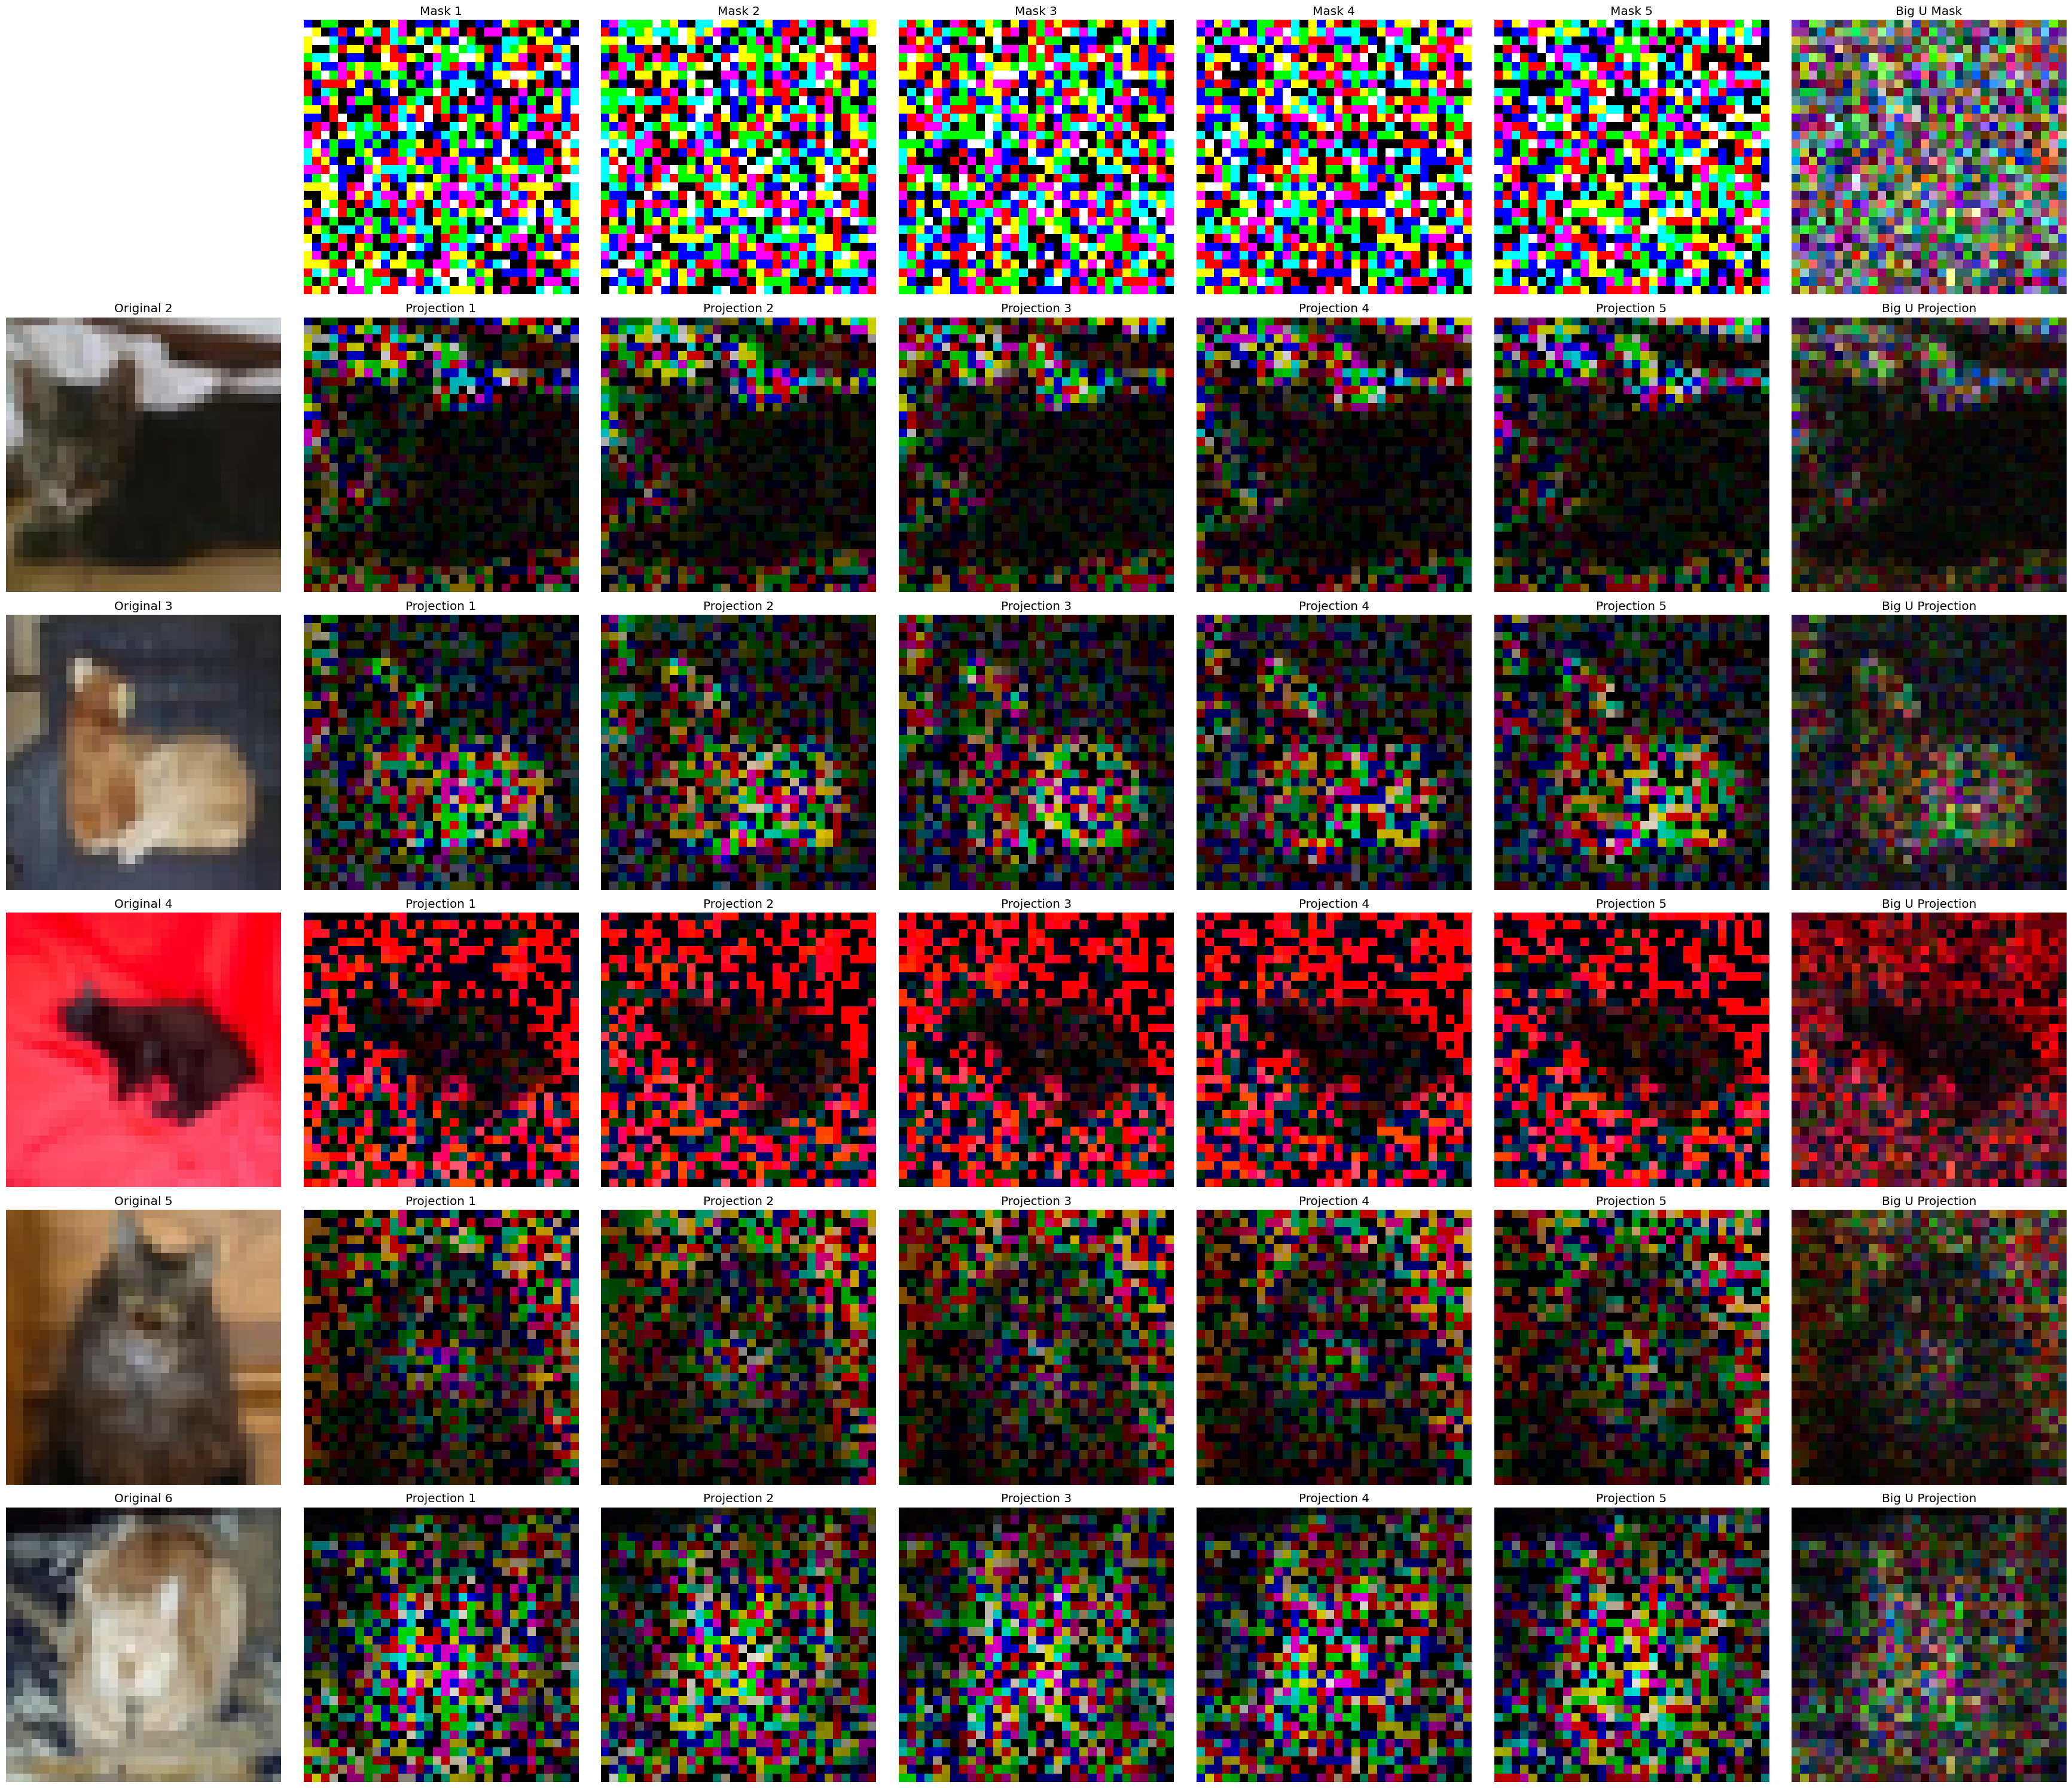

Epoch 0 of 3000


Average loss in the epoch: 0.0038287401199340824
Epoch 1 of 3000


Average loss in the epoch: 0.00361177921295166
Epoch 2 of 3000


Average loss in the epoch: 0.0038322925567626956
Epoch 3 of 3000


Average loss in the epoch: 0.0041531801223754885
Epoch 4 of 3000


...

Average loss in the epoch: 0.003748536109924317
Epoch 56 of 3000


Average loss in the epoch: 0.003302621841430664
Epoch 57 of 3000


Average loss in the epoch: 0.0034291744232177734
Epoch 58 of 3000


Average loss in the epoch: 0.0036804914474487297
Epoch 59 of 3000


KeyboardInterrupt: 

In [4]:
from src.models.generator.diagonal_matrix.three_channels.GeneratorThreeChannel import GeneratorThreeChannel
from src.vmmdref.VMMDDiagonal3Channel import VMMDDiagonal3Channel

hyperparameter_list = generate_hyperparams(n_iter=10, random_state=777)
for i in range(len(hyperparameter_list)):
    vmmd =VMMDDiagonal3Channel(
        filename=f"three_channel_hypparam_0_{i}",
        weight_decay=hyperparameter_list[i]['weight_decay'],
        seed=hyperparameter_list[i]['seed'],
        momentum=hyperparameter_list[i]['momentum'],
        lr=hyperparameter_list[i]['lr'],
        epochs=3000,
        batch_size=hyperparameter_list[i]['batch_size'],
        path_to_directory="/Users/paulenciu/PycharmProjects/V-GAN/experiments/local")
    noise_dim = hyperparameter_list[i]['latent_size']
    vmmd.fit(cats_dataset, ResNet18AutoEncoder(), GeneratorThreeChannel(noise_dim))

In [ ]:
from src.models.generator.diagonal_matrix.one_channel.GeneratorOneChannelResidual import GeneratorOneChannelResidual

hyperparameter_list = generate_hyperparams(n_iter=9, random_state=777)
for i in range(1, len(hyperparameter_list)):
    vmmd =VMMDDiagonal1Channel(
        filename=f"one_channel_hypparam_0_{i}",
        weight_decay=hyperparameter_list[i]['weight_decay'],
        seed=hyperparameter_list[i]['seed'],
        momentum=hyperparameter_list[i]['momentum'],
        lr=hyperparameter_list[i]['lr'],
        epochs=hyperparameter_list[i]['epochs'],
        batch_size=hyperparameter_list[i]['batch_size'],
        path_to_directory="/home/i40/enciup/V-GAN/experiments/remote")
    noise_dim = hyperparameter_list[i]['latent_size']
    vmmd.fit(cats_dataset, ResNet18AutoEncoder(), GeneratorOneChannelResidual(noise_dim))

Count:  500 PVal:  1.0
The show option has been depricated due to lack of utility


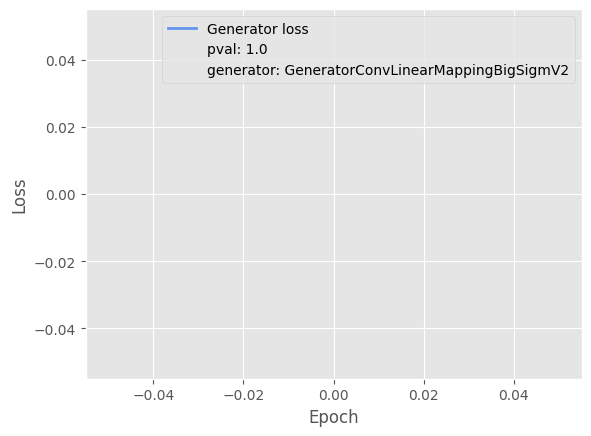

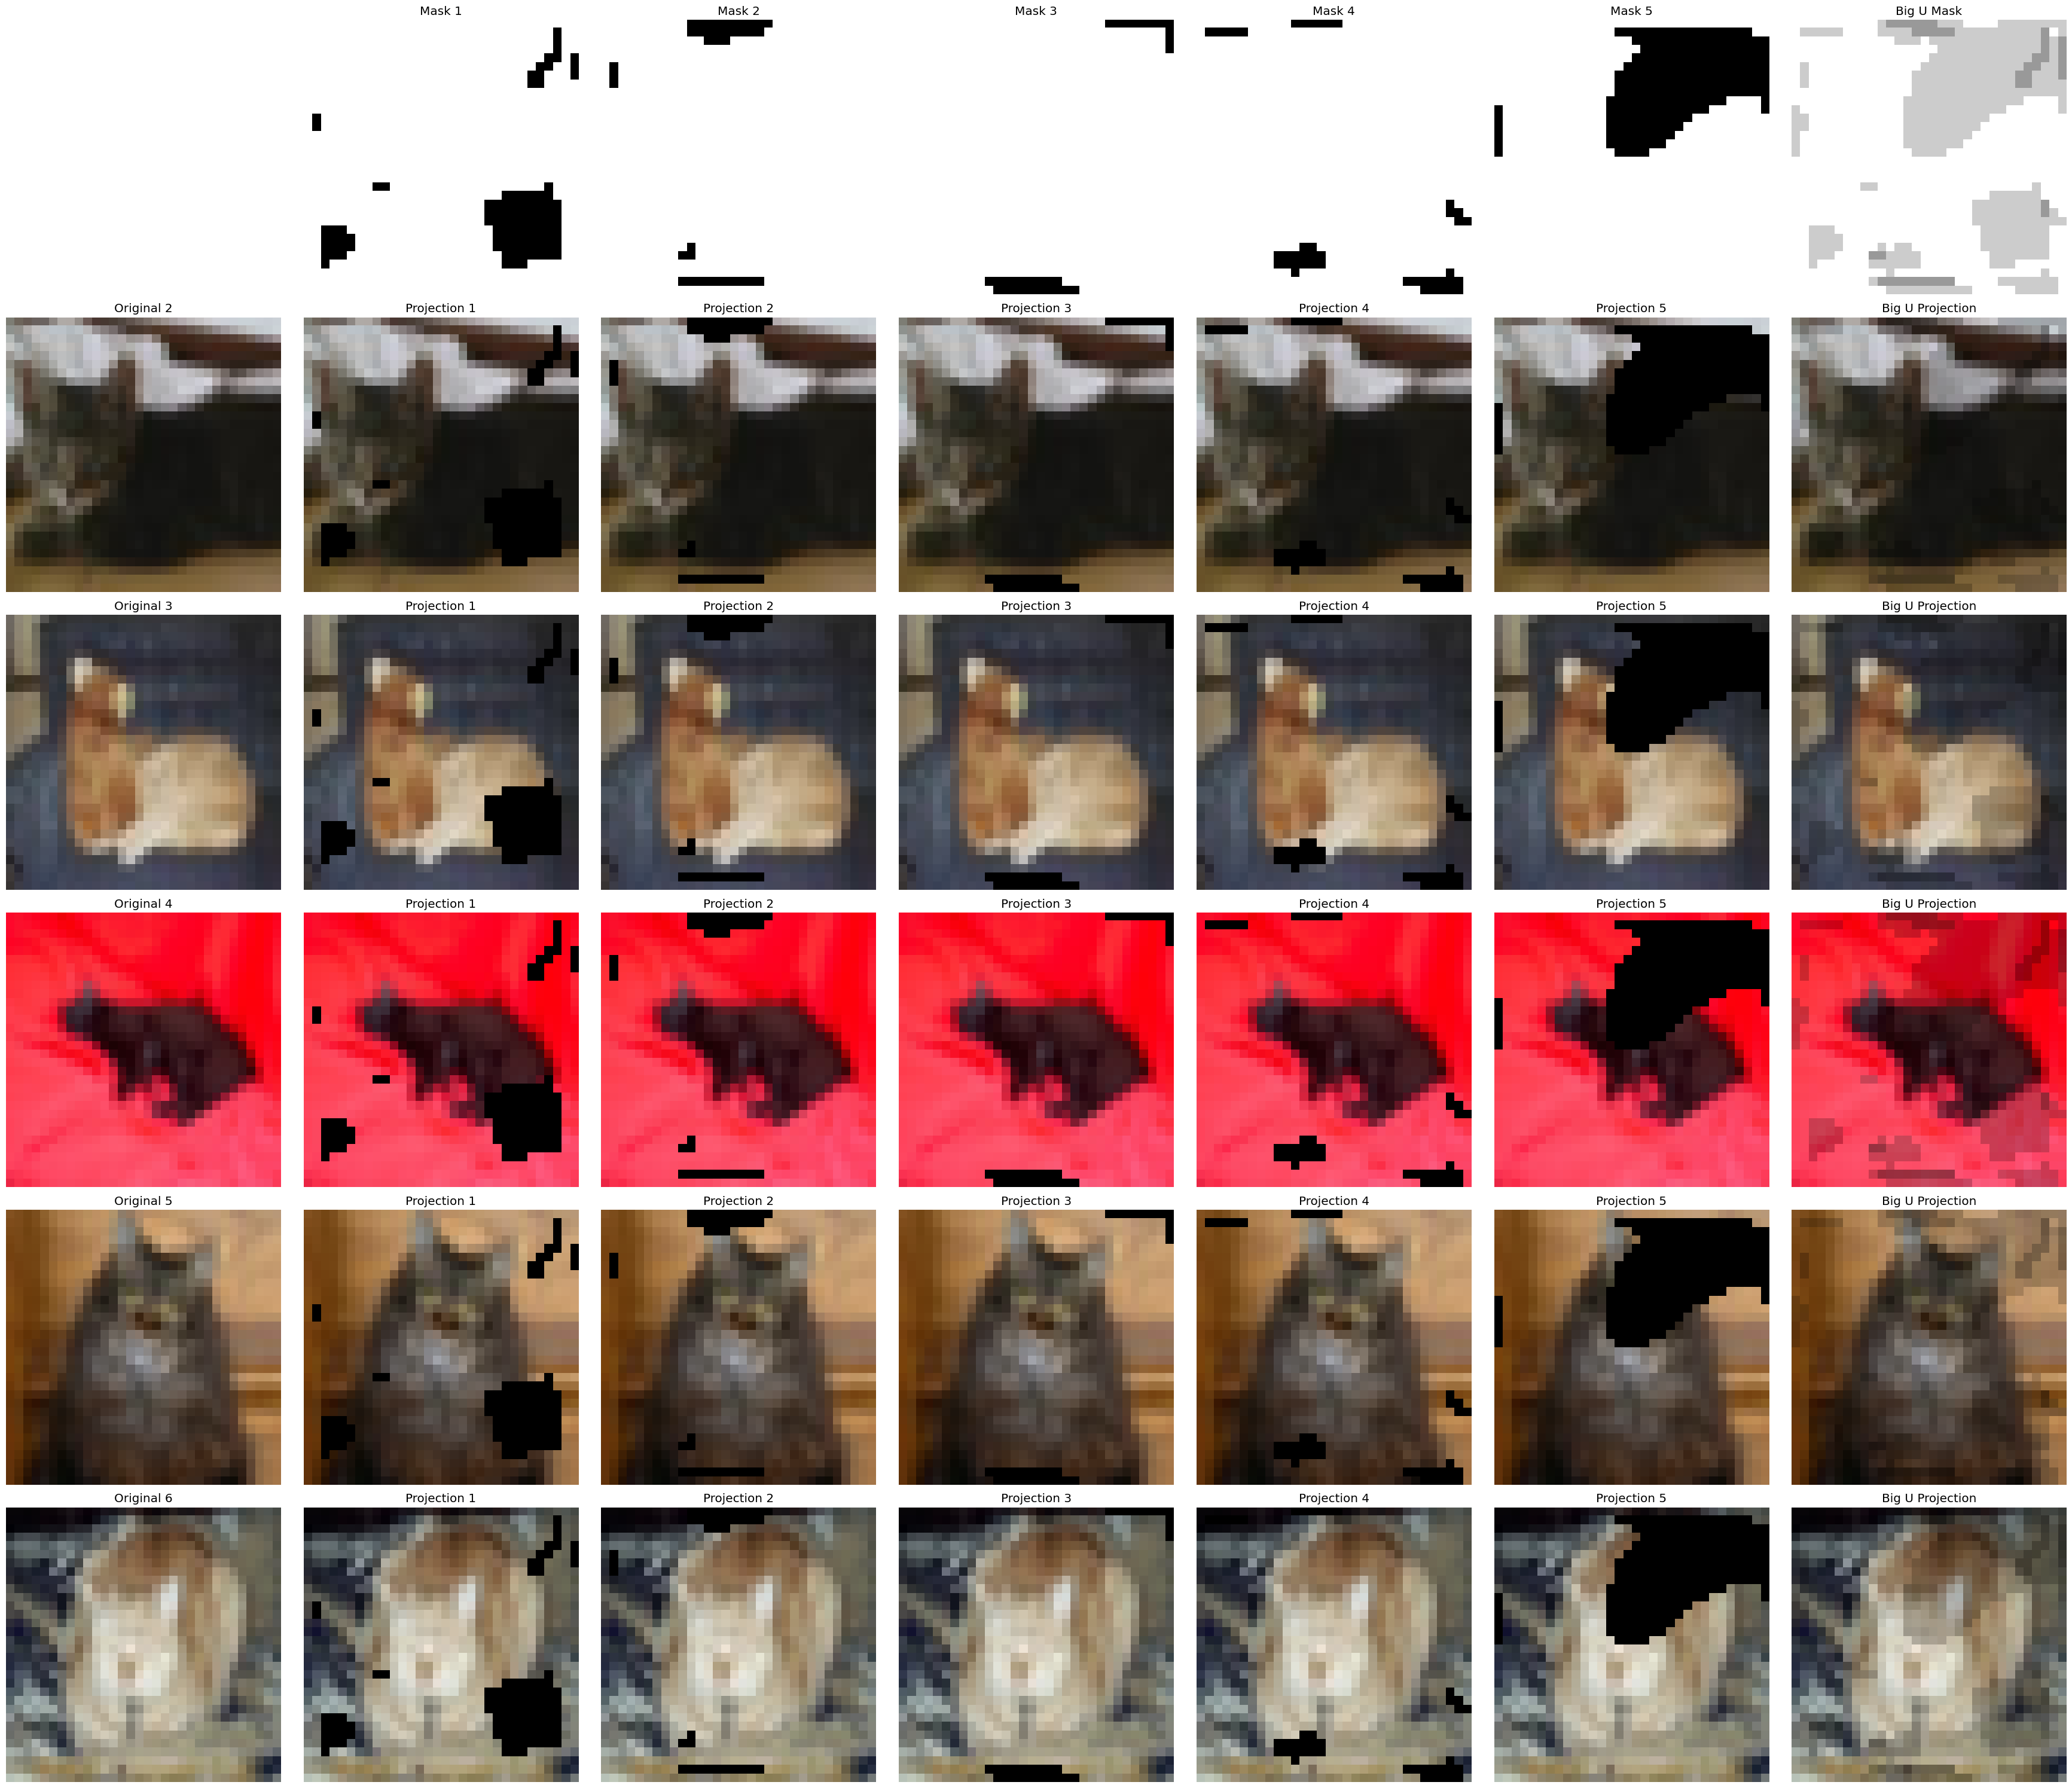

Epoch 0 of 100


Average loss in the epoch: 0.025388036109507083
Epoch 1 of 100


Average loss in the epoch: 0.020080648921430112
Epoch 2 of 100


Average loss in the epoch: 0.022650770284235476
Epoch 3 of 100


Average loss in the epoch: 0.02438118755817413
Epoch 4 of 100


...

Average loss in the epoch: 0.023842684924602505
Epoch 22 of 100


Average loss in the epoch: 0.023423710092902183
Epoch 23 of 100


Average loss in the epoch: 0.023558539152145386
Epoch 24 of 100


Average loss in the epoch: 0.023987673968076703
Epoch 25 of 100


Count:  500 PVal:  1.0
The show option has been depricated due to lack of utility


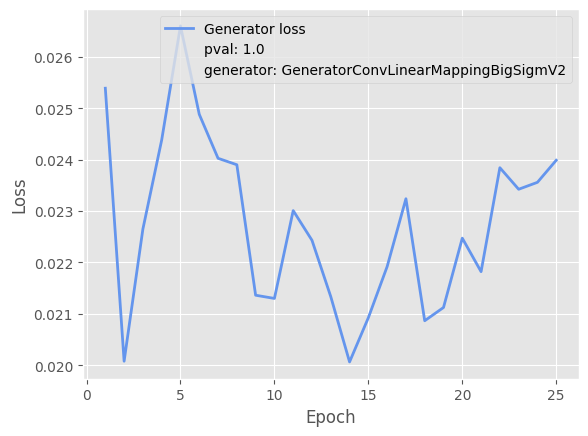

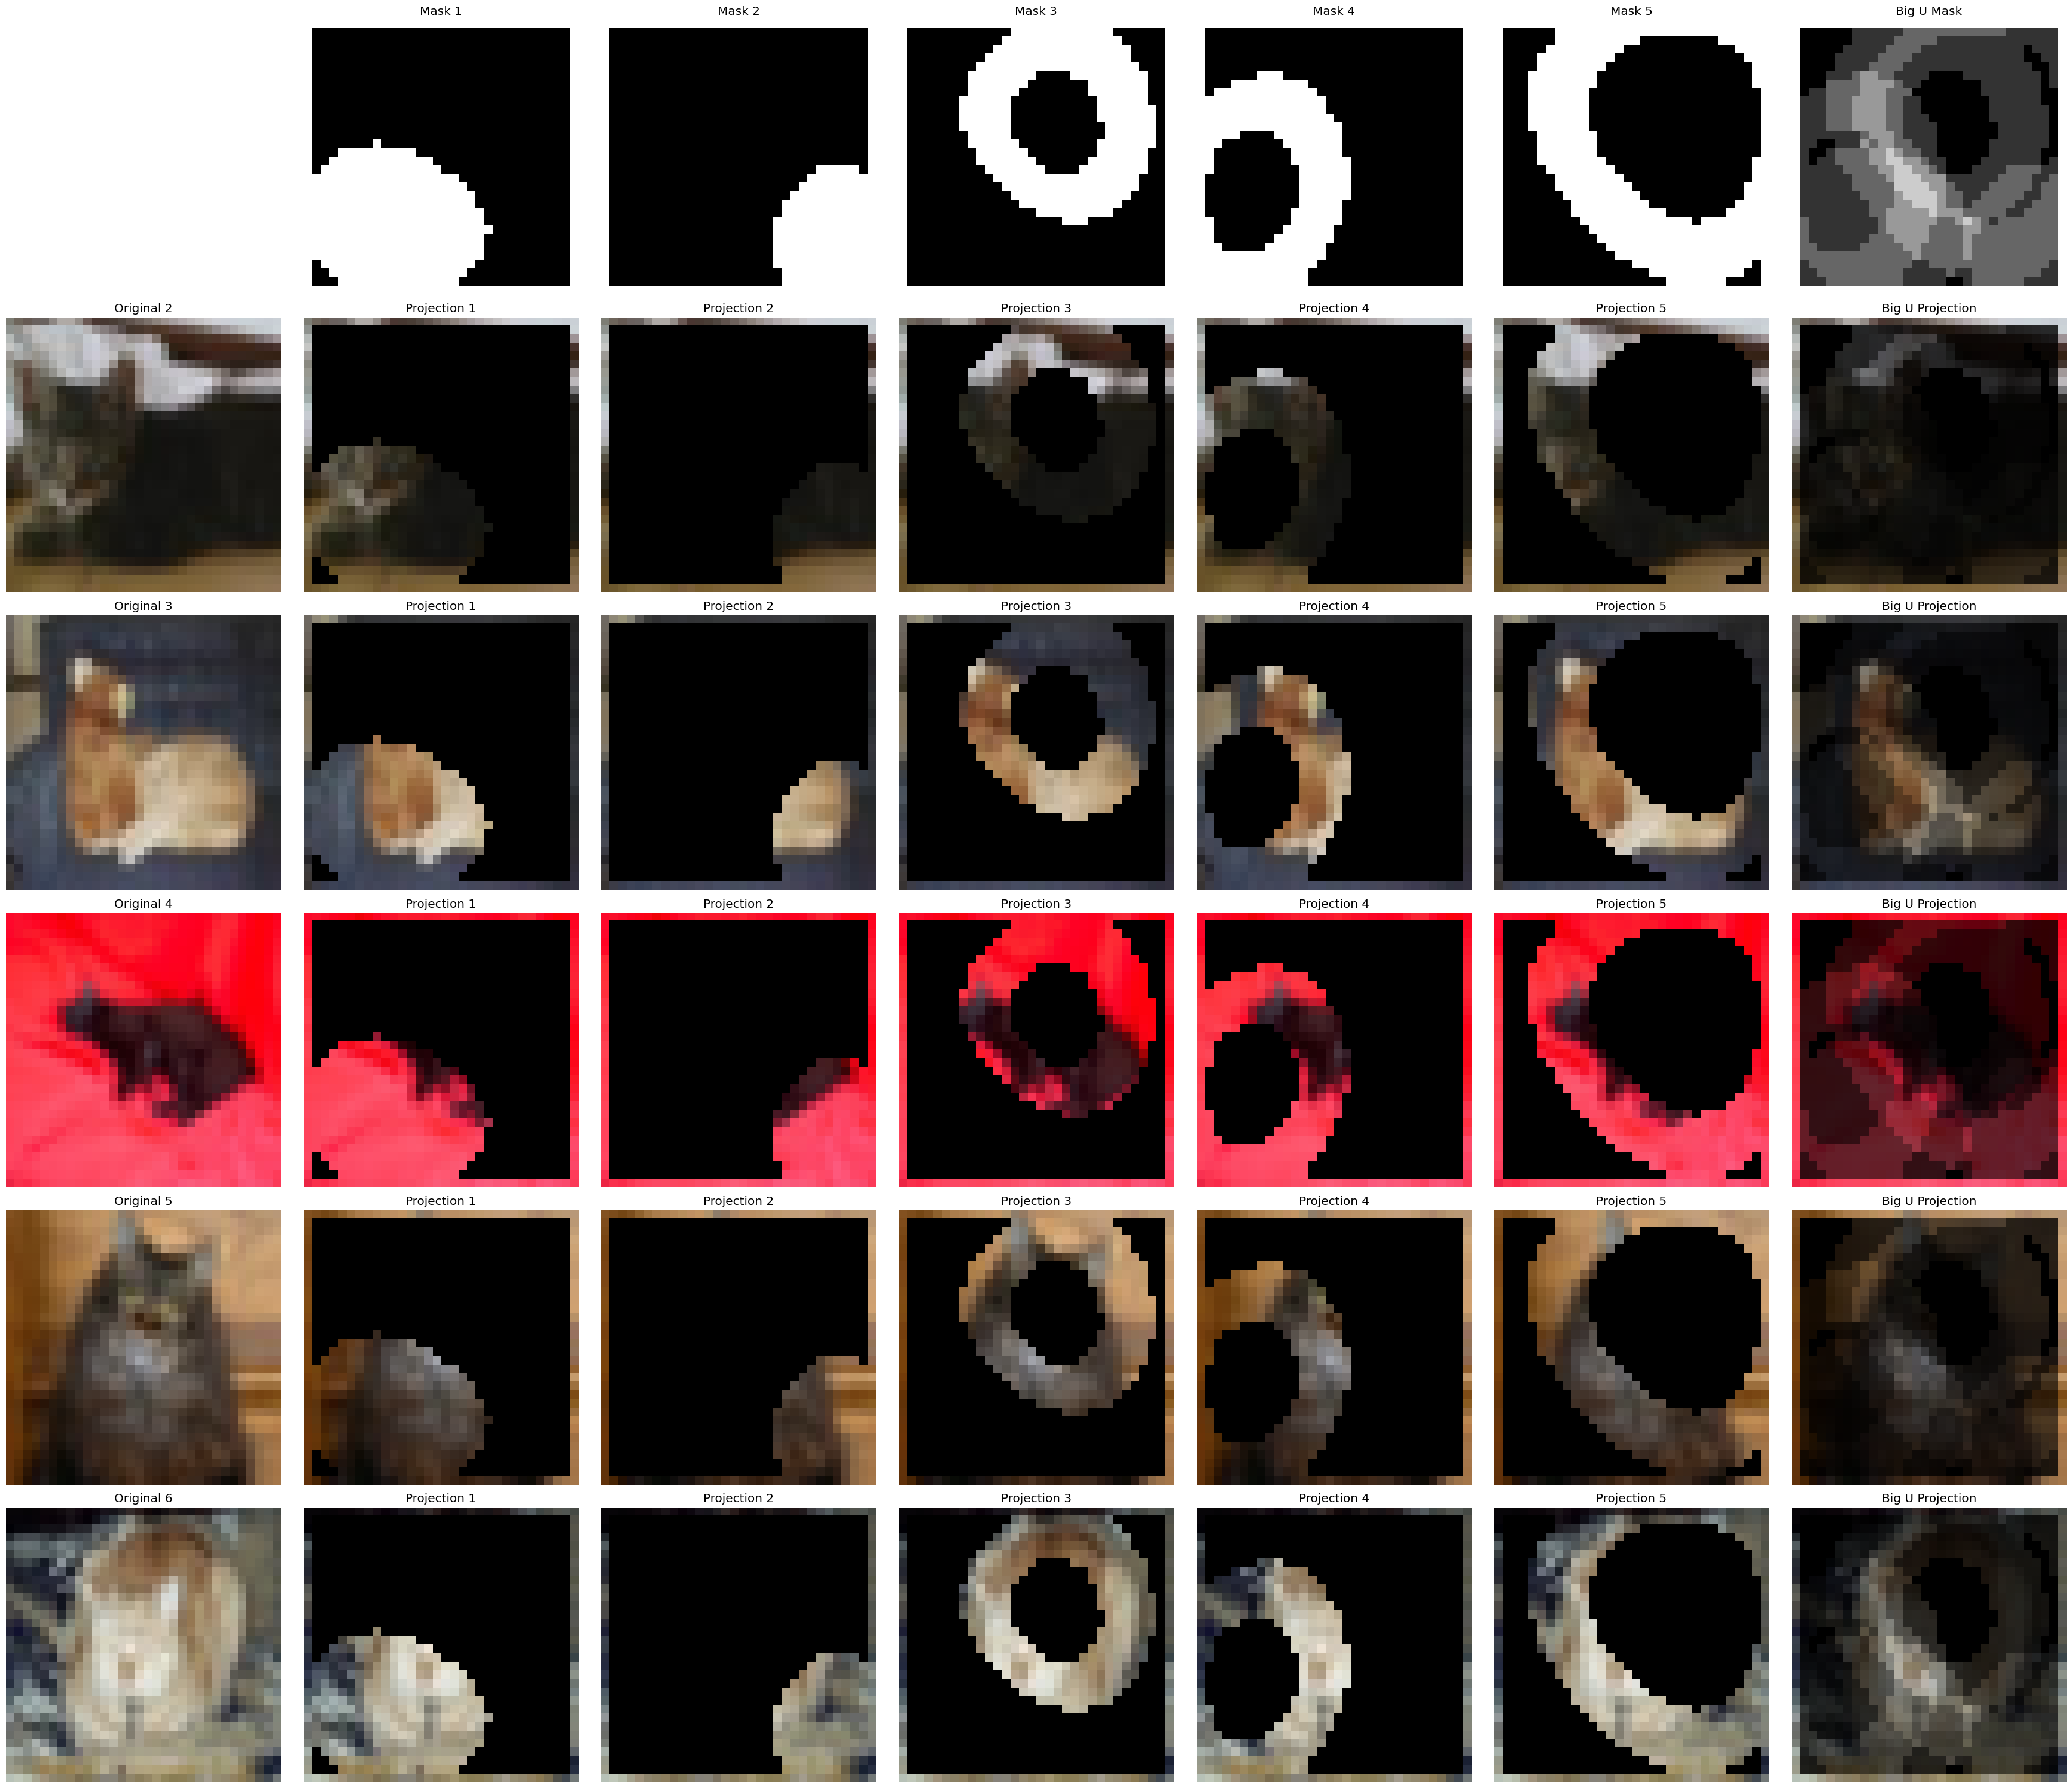

Average loss in the epoch: 0.02354983929544687
Epoch 26 of 100


Average loss in the epoch: 0.02335578799247742
Epoch 27 of 100


Average loss in the epoch: 0.024627158977091314
Epoch 28 of 100


Average loss in the epoch: 0.02545761317014694
Epoch 29 of 100


Average loss in the epoch: 0.023176250234246253
Epoch 30 of 100


...

Average loss in the epoch: 0.02851618099957704
Epoch 47 of 100


Average loss in the epoch: 0.02878370117396116
Epoch 48 of 100


Average loss in the epoch: 0.029111837595701216
Epoch 49 of 100


Average loss in the epoch: 0.029474803619086744
Epoch 50 of 100


Count:  500 PVal:  1.0
The show option has been depricated due to lack of utility


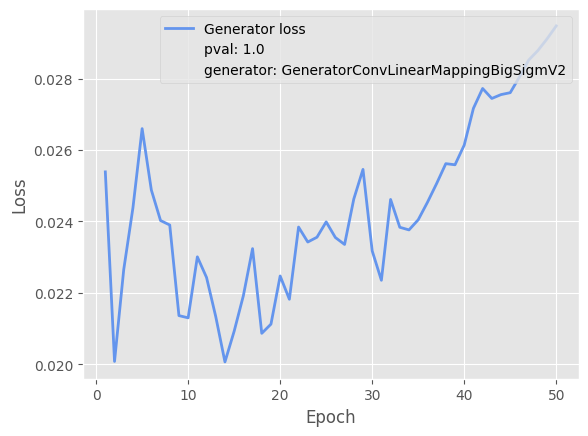

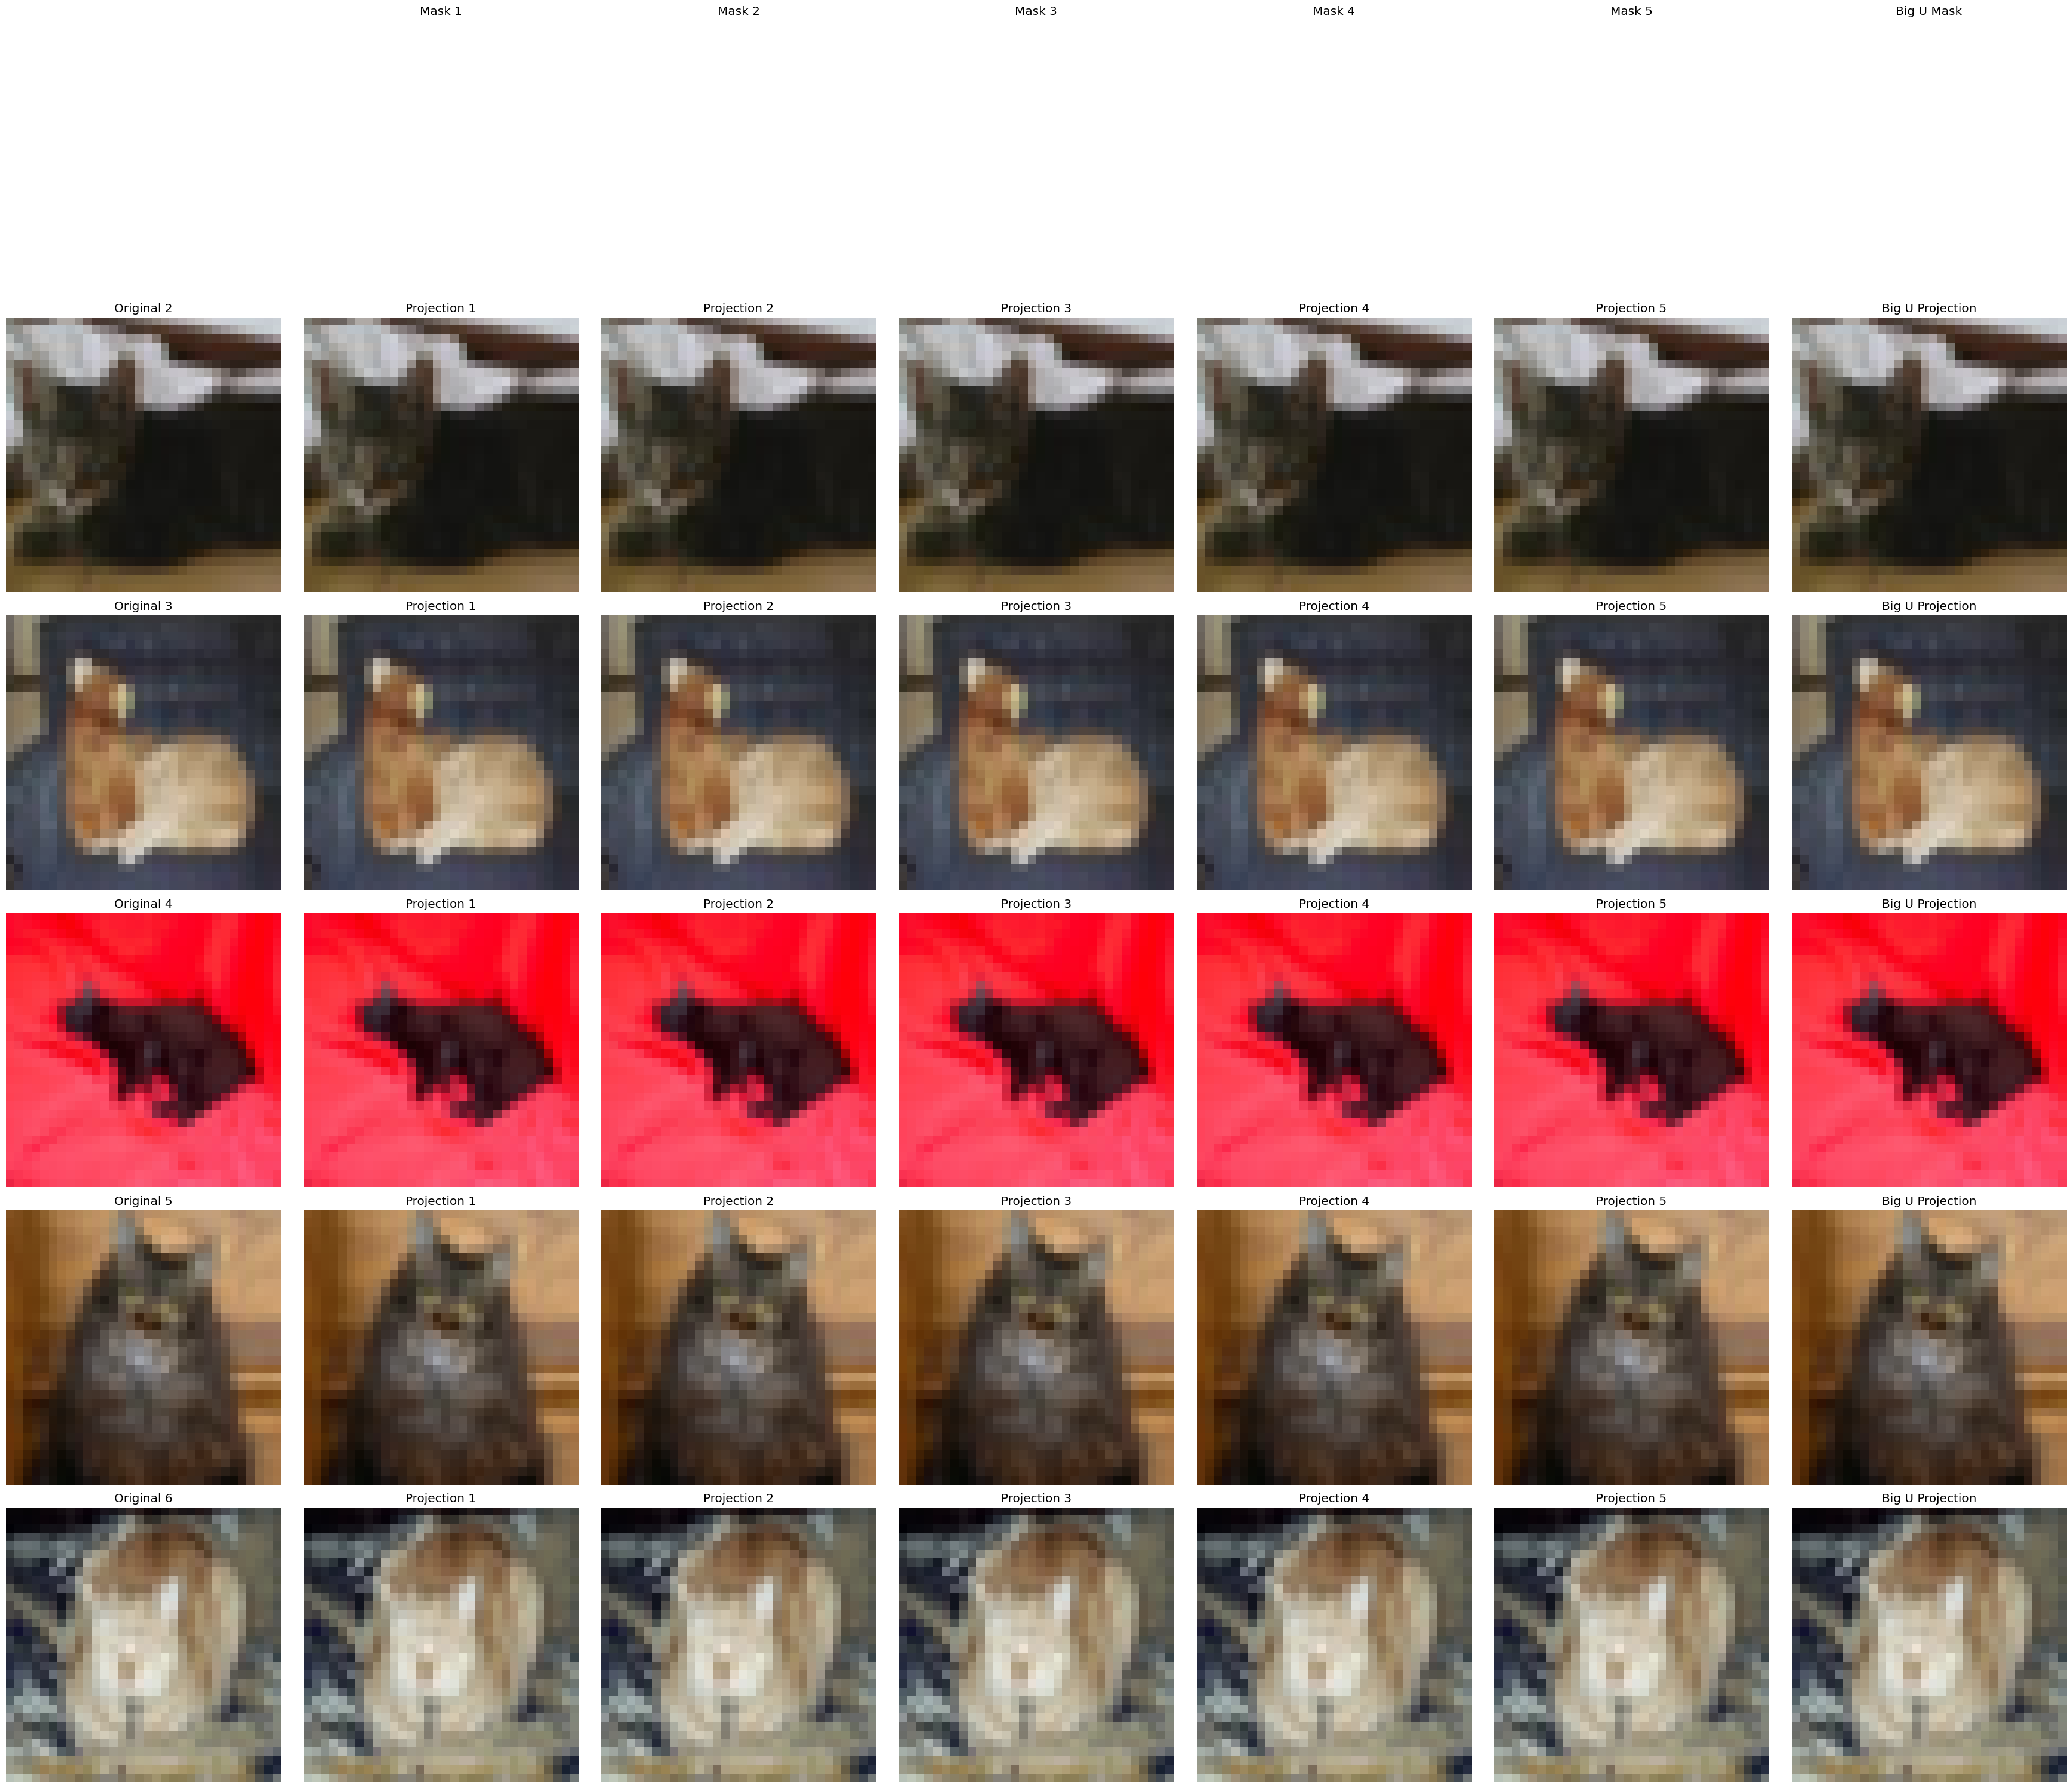

Average loss in the epoch: 0.029831208661198618
Epoch 51 of 100


Average loss in the epoch: 0.03015180602669716
Epoch 52 of 100


Average loss in the epoch: 0.030432430654764177
Epoch 53 of 100


Average loss in the epoch: 0.030684818141162393
Epoch 54 of 100


Average loss in the epoch: 0.030880504474043842
Epoch 55 of 100


...

Average loss in the epoch: 0.030983884632587434
Epoch 72 of 100


Average loss in the epoch: 0.03098369836807251
Epoch 73 of 100


Average loss in the epoch: 0.030983817577362065
Epoch 74 of 100


Average loss in the epoch: 0.030983793735504153
Epoch 75 of 100


Count:  500 PVal:  1.0
The show option has been depricated due to lack of utility


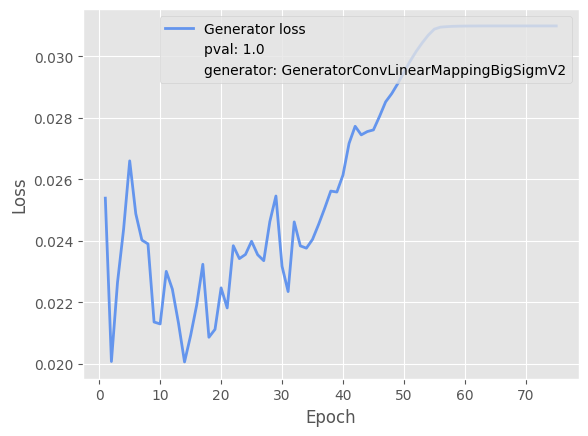

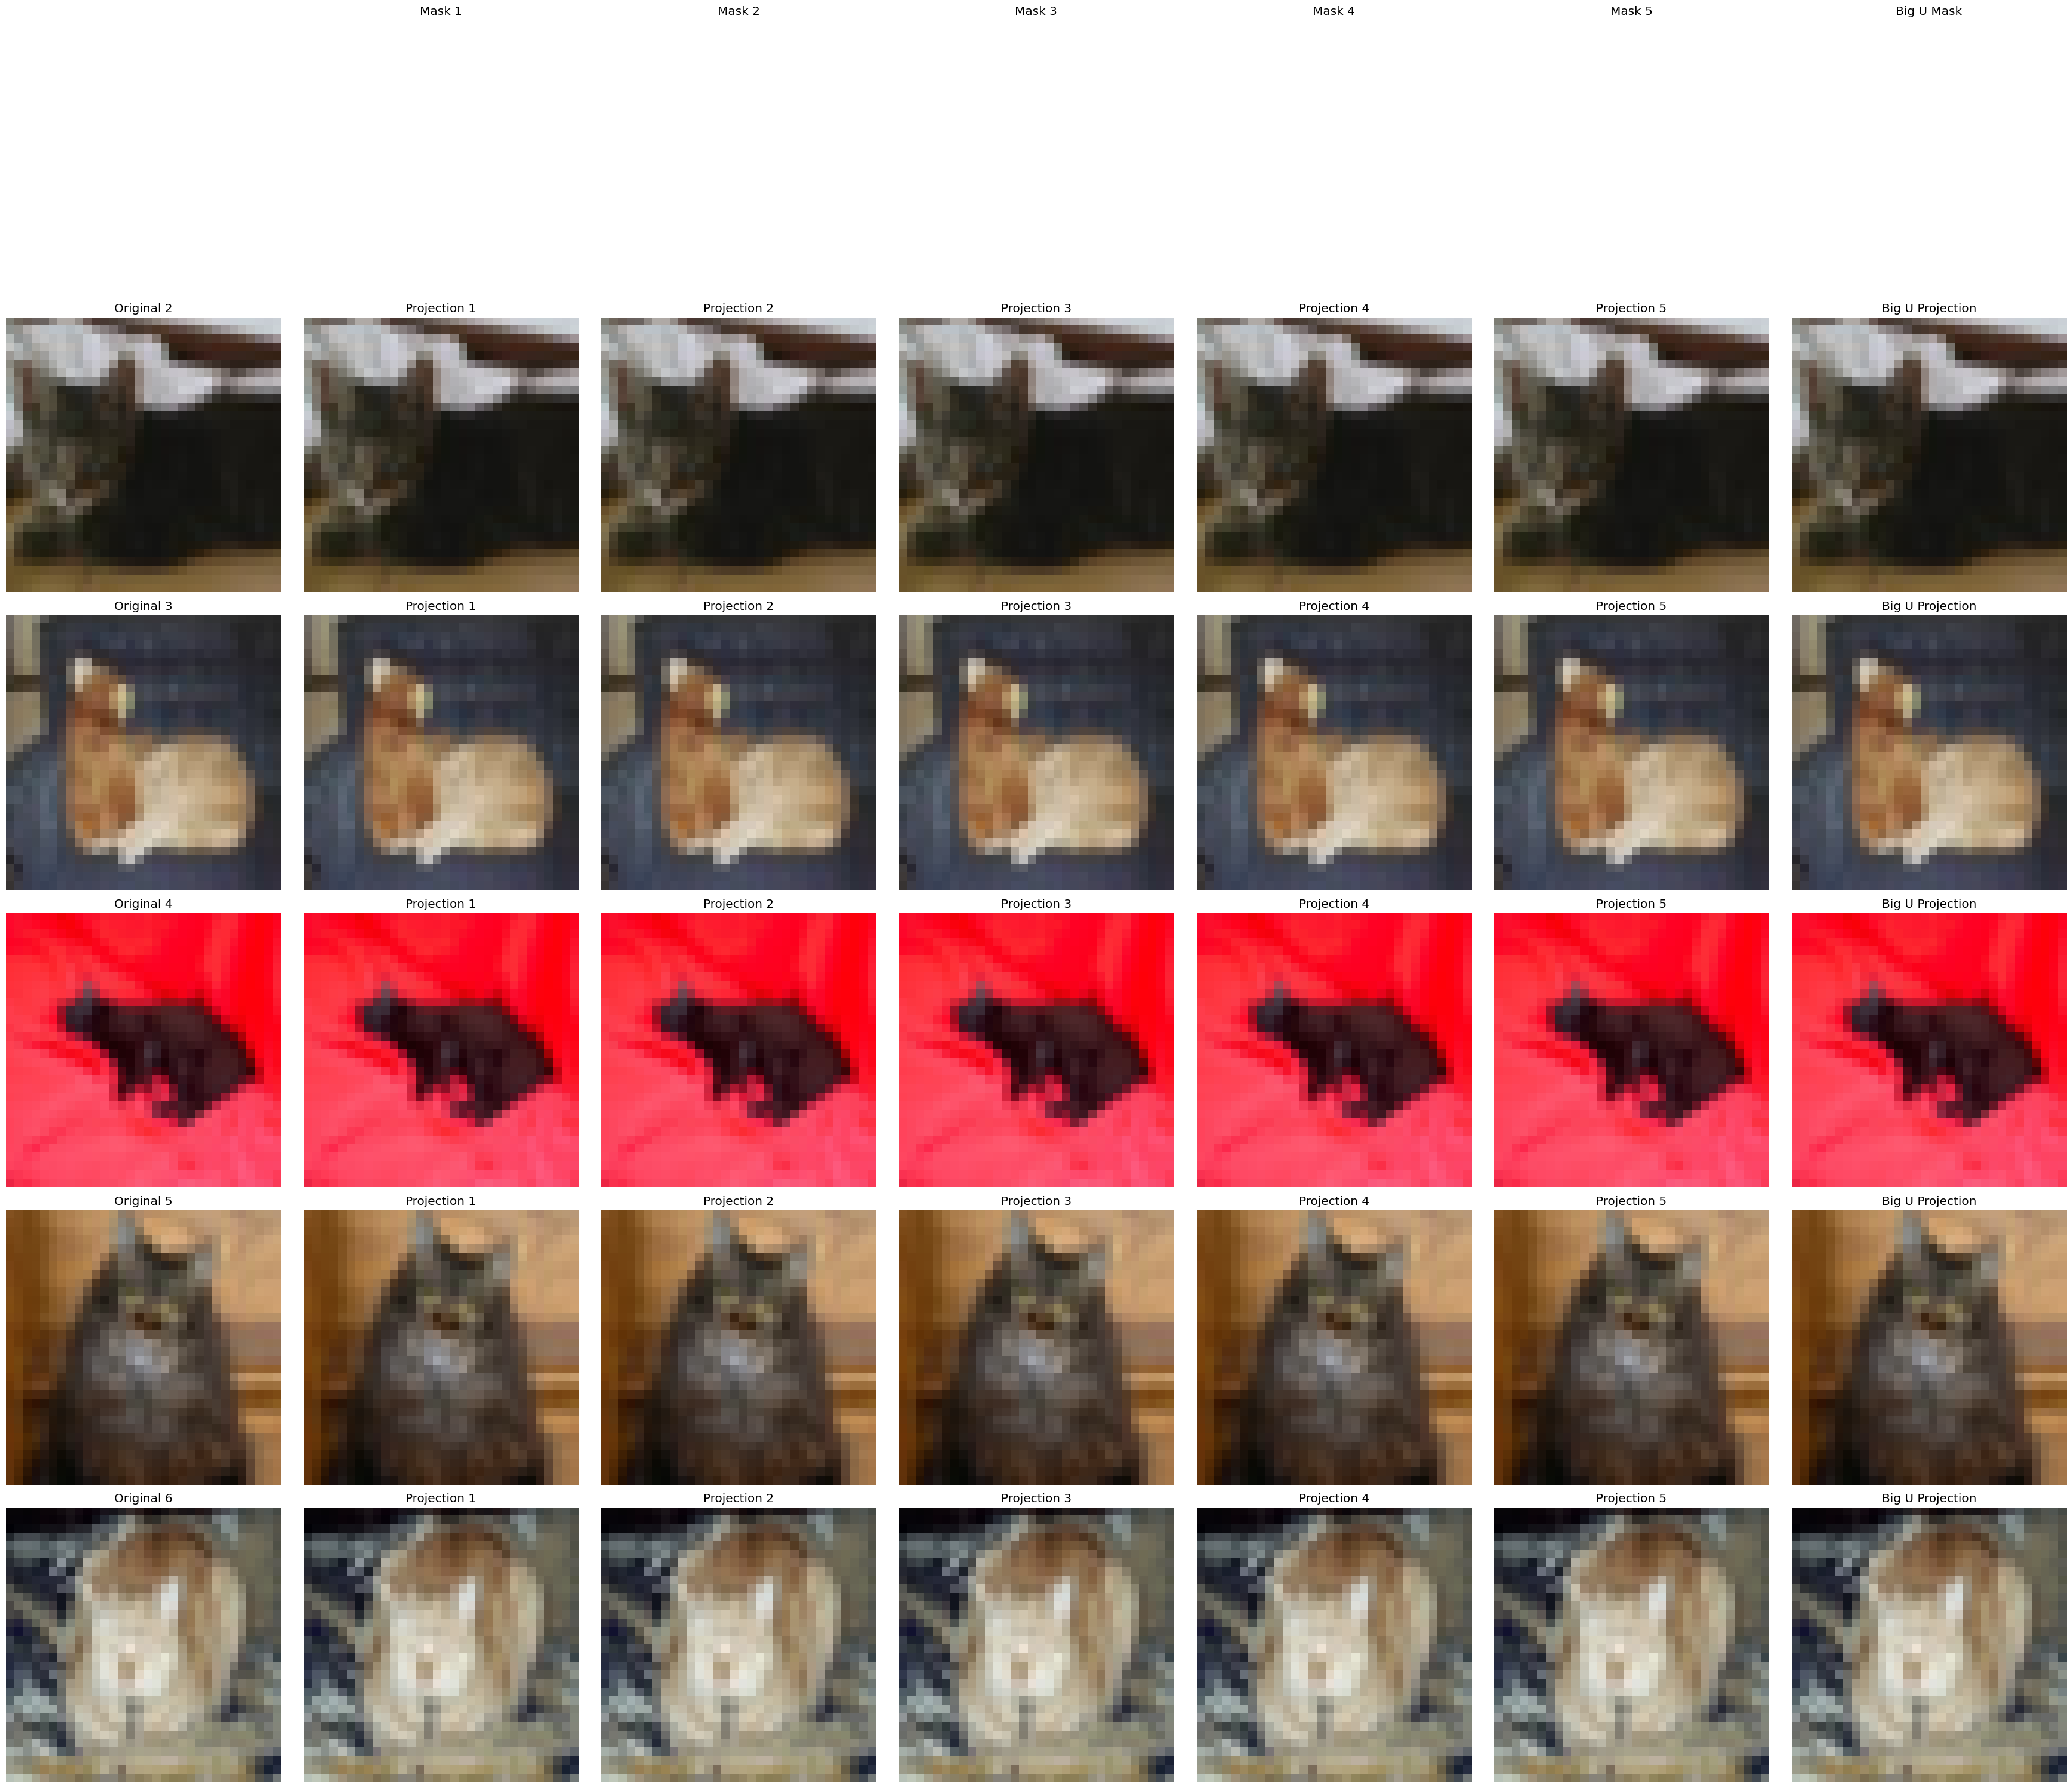

Average loss in the epoch: 0.03098398447036743
Epoch 76 of 100


Average loss in the epoch: 0.030983865261077884
Epoch 77 of 100


Average loss in the epoch: 0.03098376989364624
Epoch 78 of 100


Average loss in the epoch: 0.03098379373550415
Epoch 79 of 100


Average loss in the epoch: 0.03098376989364624
Epoch 80 of 100


...

Average loss in the epoch: 0.03098393678665161
Epoch 96 of 100


Average loss in the epoch: 0.030983865261077884
Epoch 97 of 100


Average loss in the epoch: 0.0309836745262146
Epoch 98 of 100


Average loss in the epoch: 0.030983817577362065
Epoch 99 of 100


Average loss in the epoch: 0.030983793735504153
Count:  500 PVal:  1.0
The show option has been depricated due to lack of utility


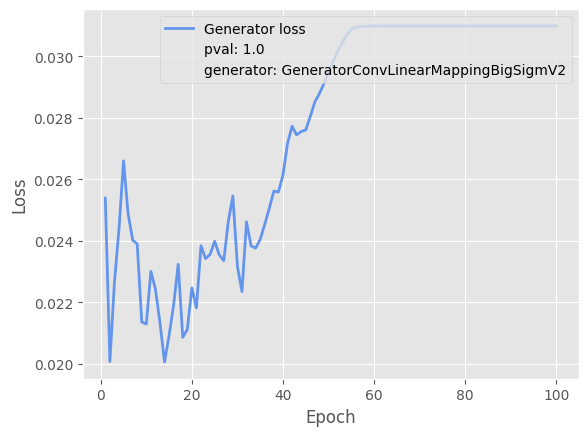

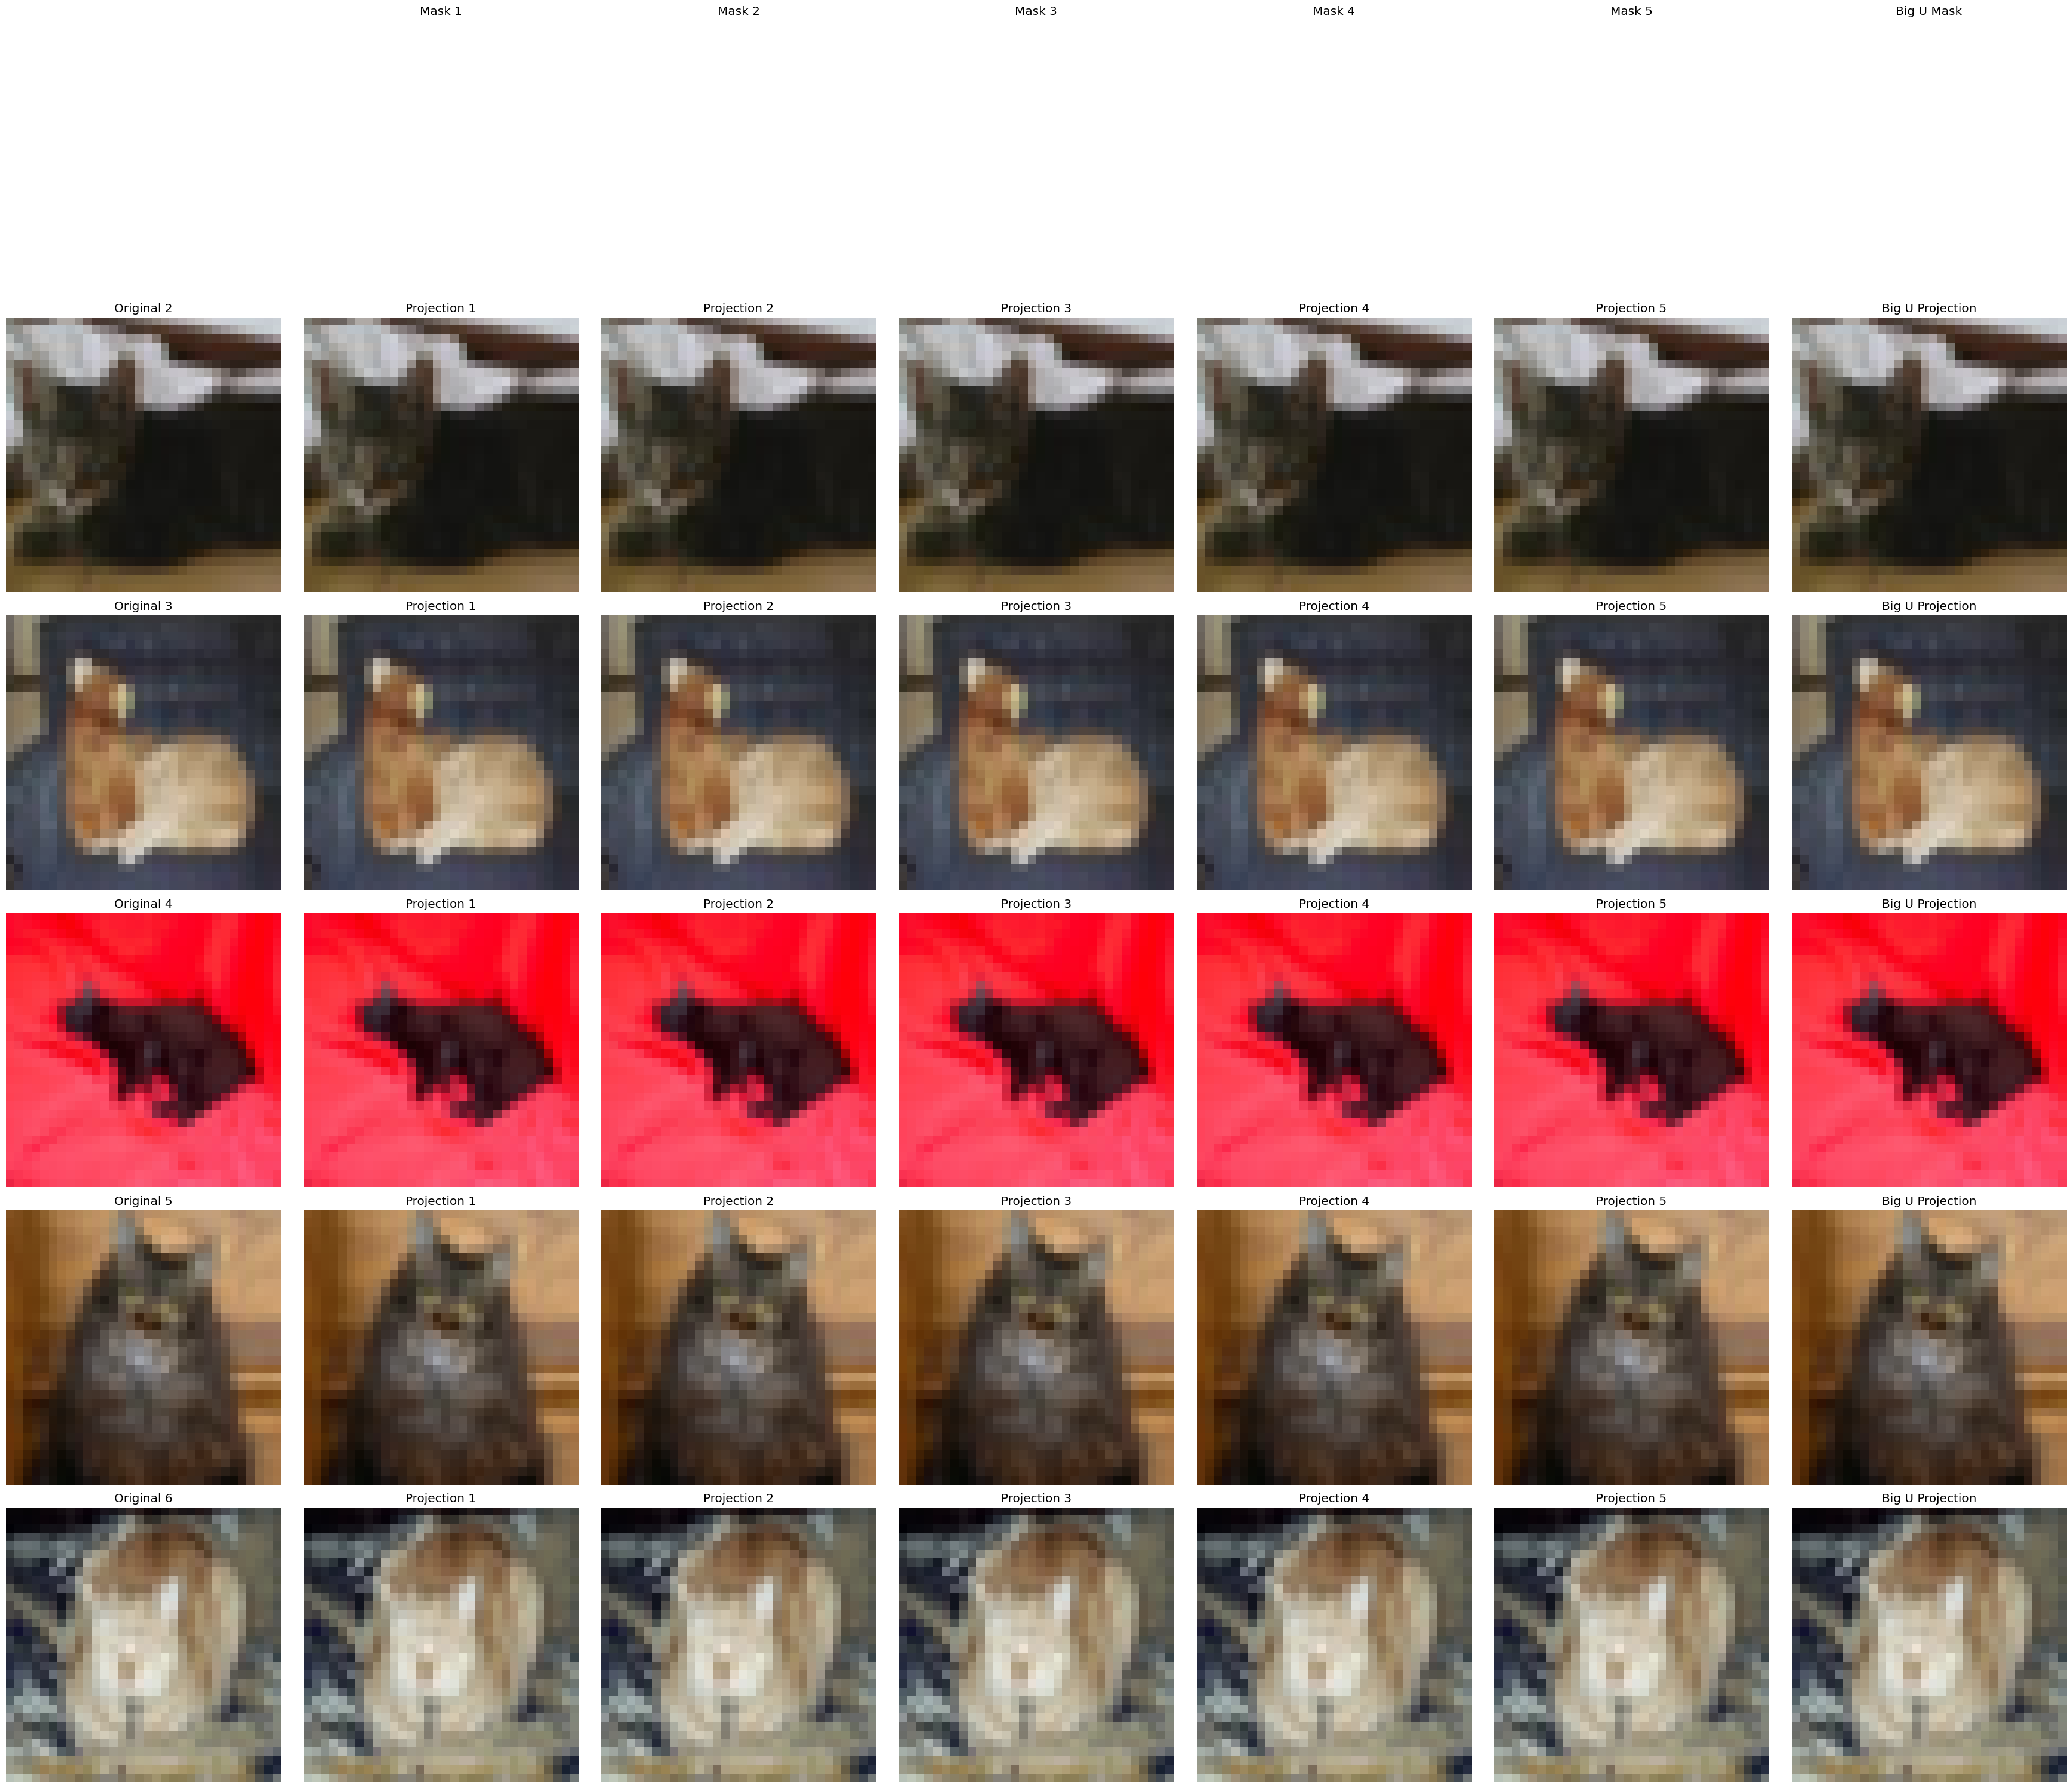

Count:  500 PVal:  1.0
The show option has been depricated due to lack of utility


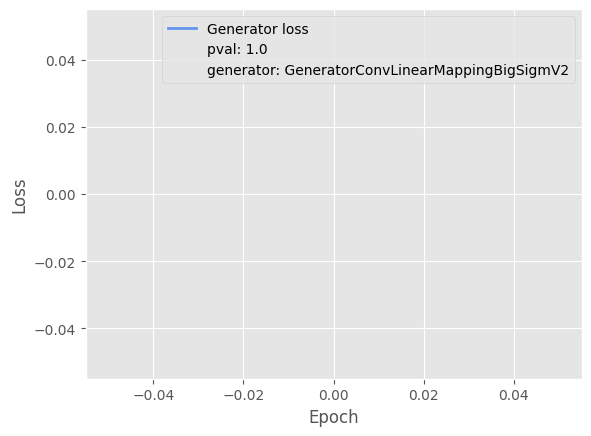

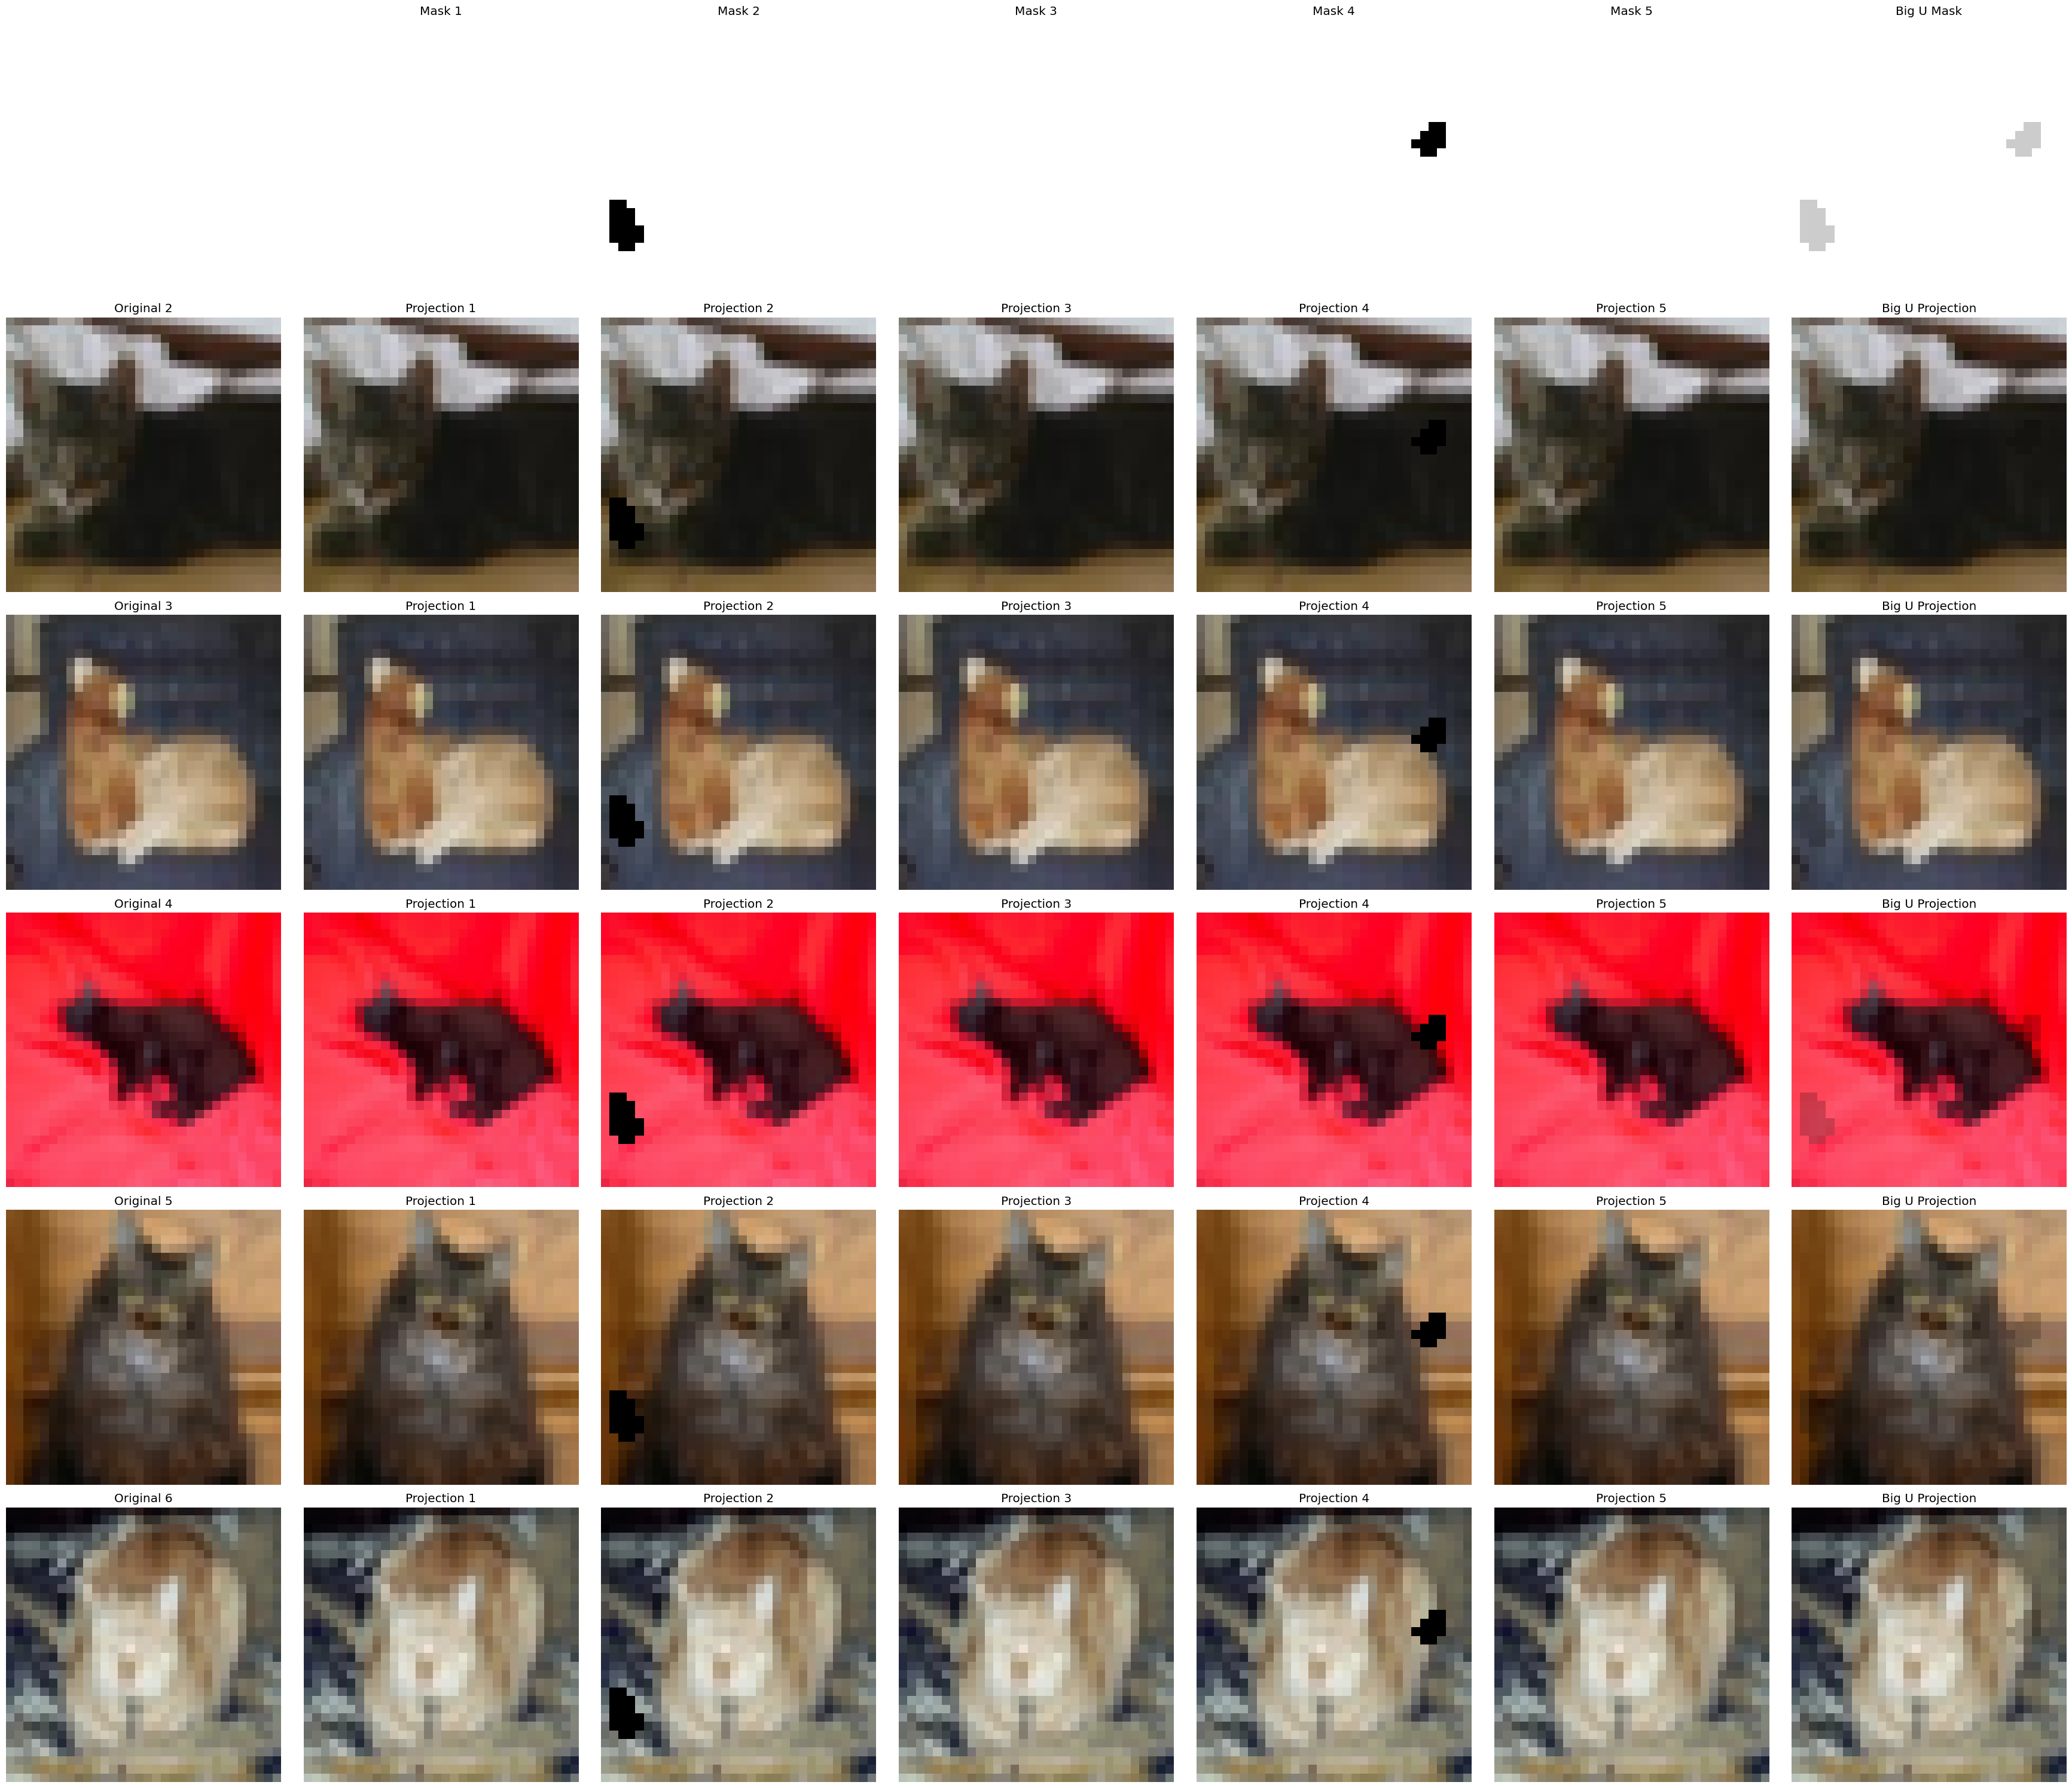

Epoch 0 of 100


Average loss in the epoch: 0.042968347668647766
Epoch 1 of 100


Average loss in the epoch: 0.028491008561104536
Epoch 2 of 100


Average loss in the epoch: 0.020720933564007282
Epoch 3 of 100


Average loss in the epoch: 0.02530284086242318
Epoch 4 of 100


...

Average loss in the epoch: 0.027793246787041426
Epoch 22 of 100


Average loss in the epoch: 0.02692341385409236
Epoch 23 of 100


Average loss in the epoch: 0.02738117380067706
Epoch 24 of 100


Average loss in the epoch: 0.02521878806874156
Epoch 25 of 100


Count:  500 PVal:  0.0
The show option has been depricated due to lack of utility


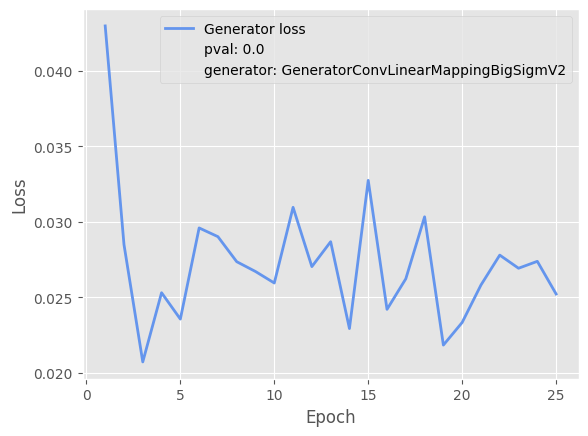

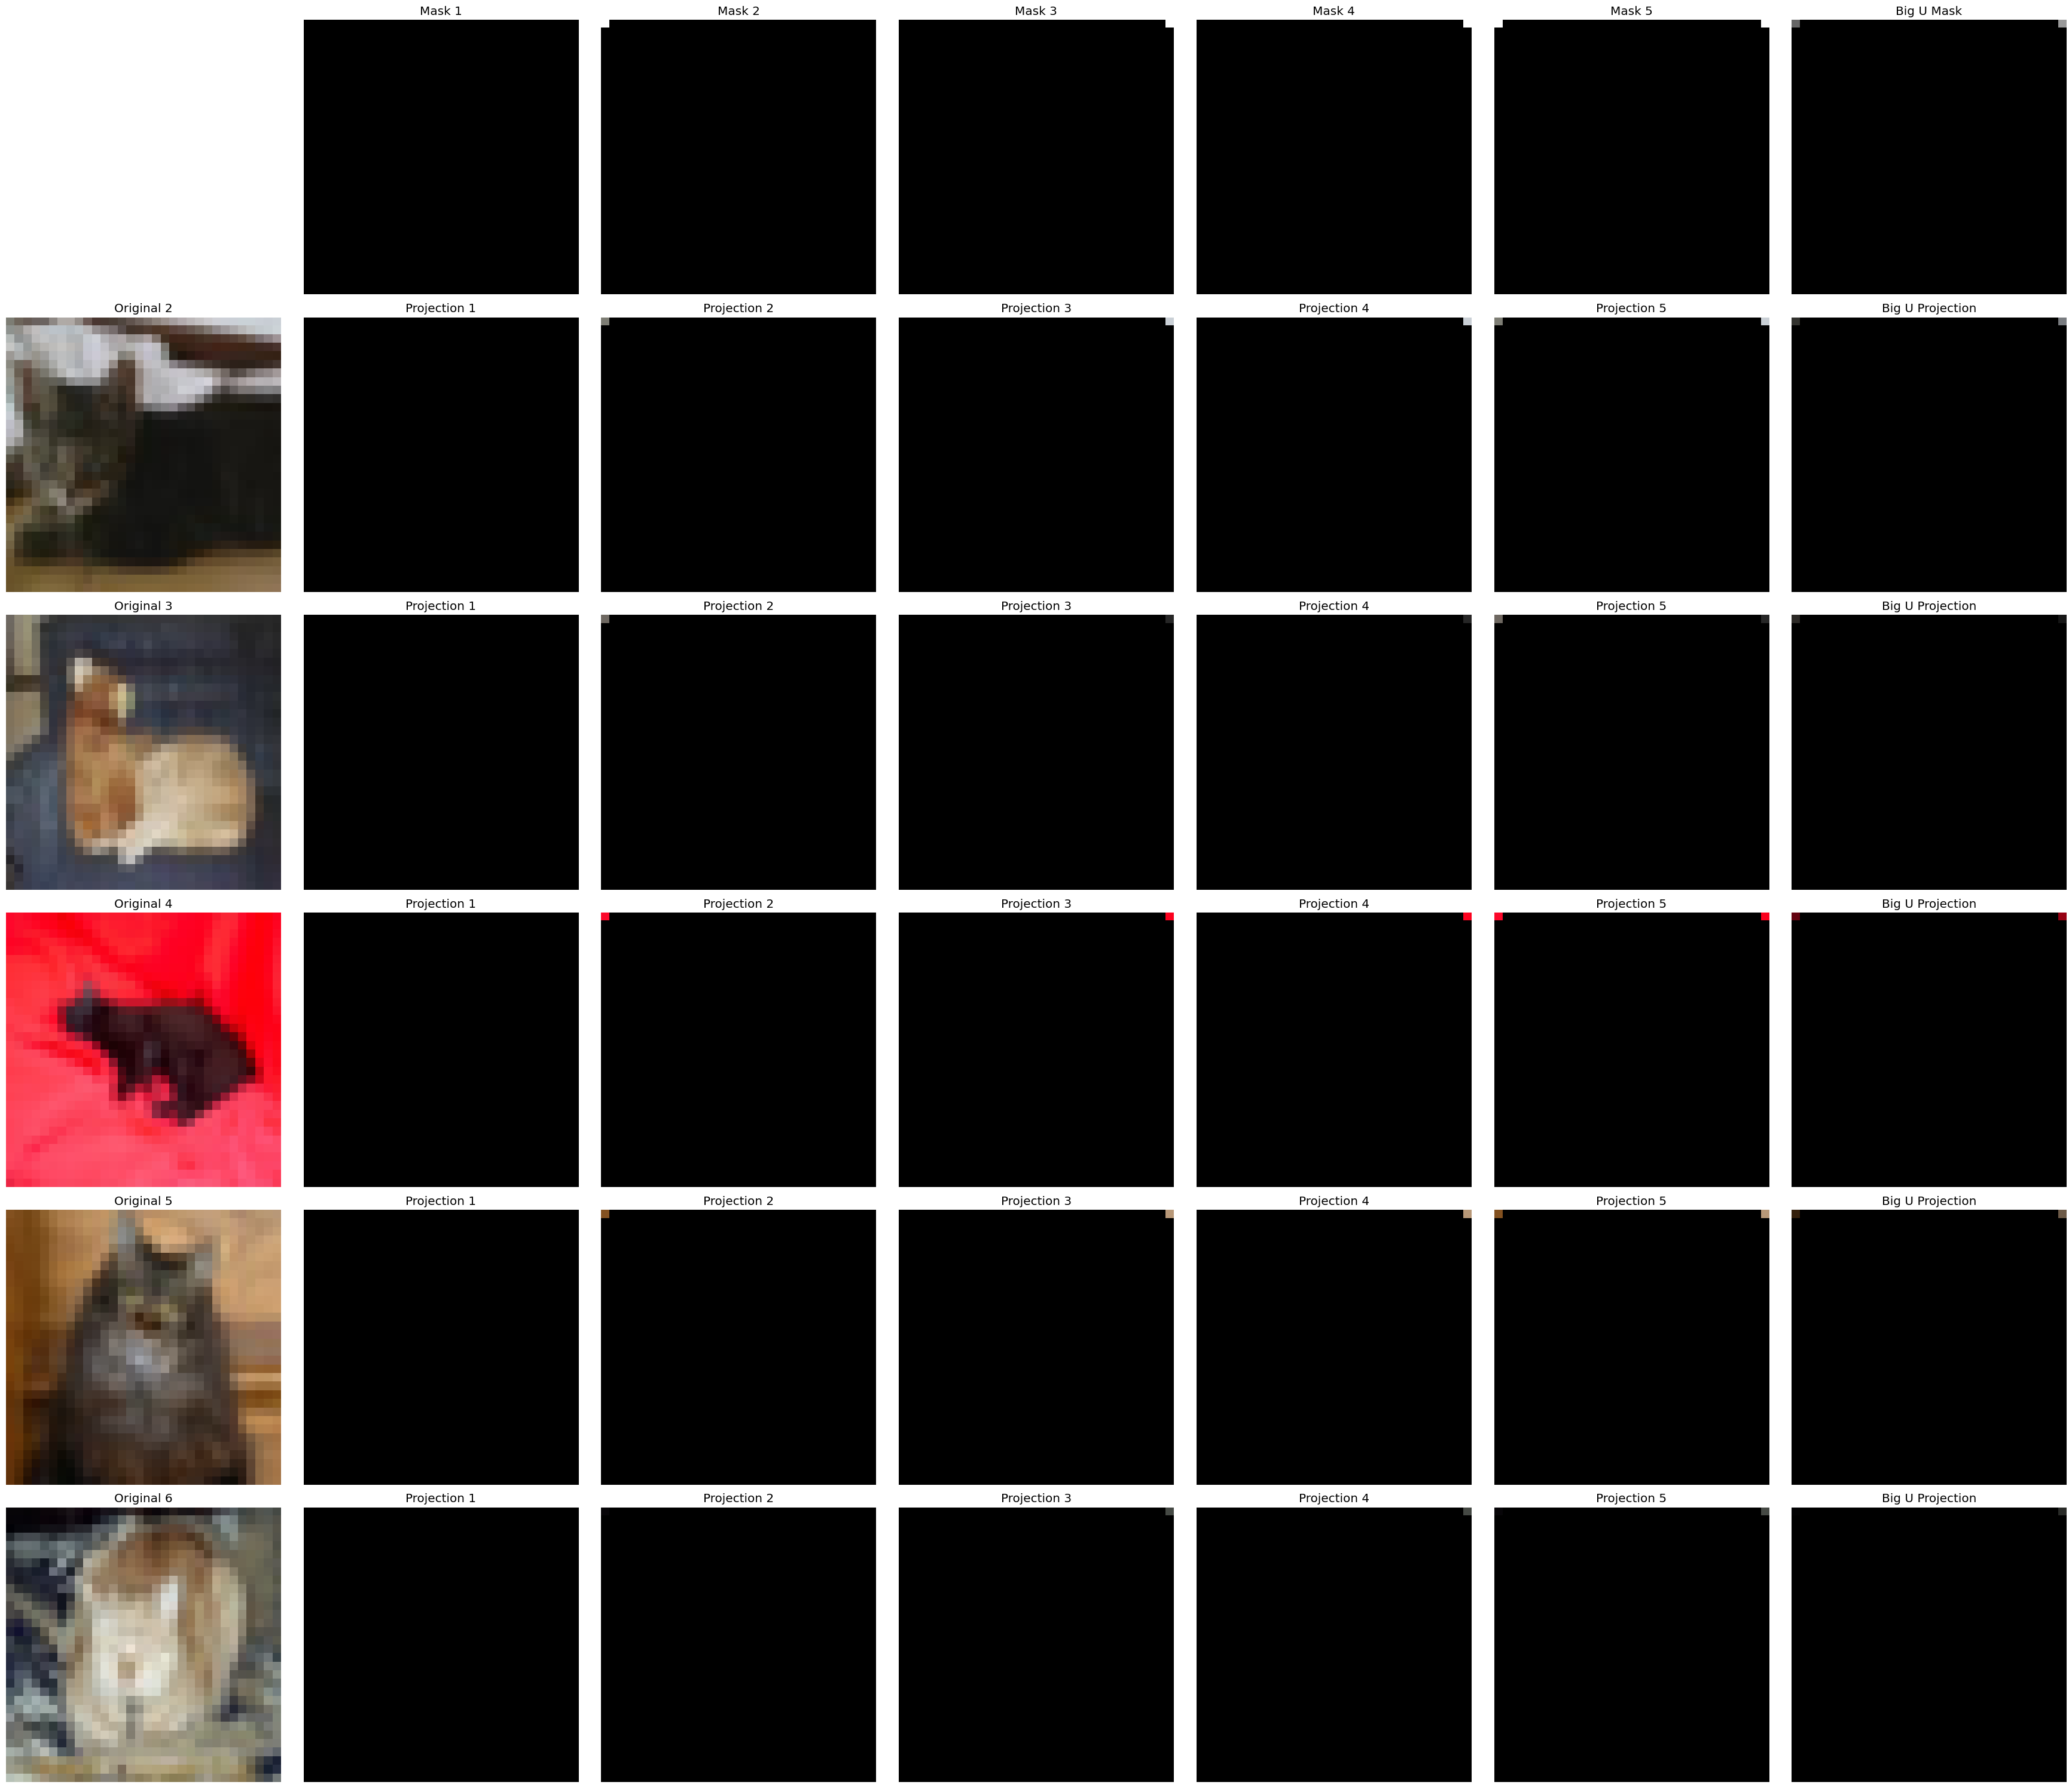

Average loss in the epoch: 0.025540714152157307
Epoch 26 of 100


Average loss in the epoch: 0.01701281126588583
Epoch 27 of 100


Average loss in the epoch: 0.01682904874905944
Epoch 28 of 100


Average loss in the epoch: 0.028181453235447407
Epoch 29 of 100


Average loss in the epoch: 0.021792526356875896
Epoch 30 of 100


...

Average loss in the epoch: 0.044340436812490225
Epoch 47 of 100


Average loss in the epoch: 0.027626883704215288
Epoch 48 of 100


Average loss in the epoch: 0.02446891786530614
Epoch 49 of 100


Average loss in the epoch: 0.023357420694082975
Epoch 50 of 100


Count:  500 PVal:  1.0
The show option has been depricated due to lack of utility


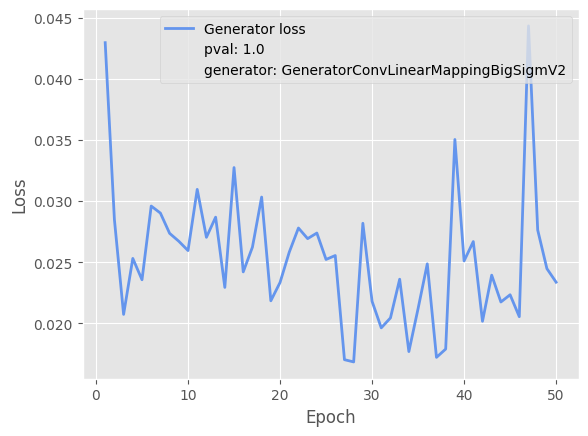

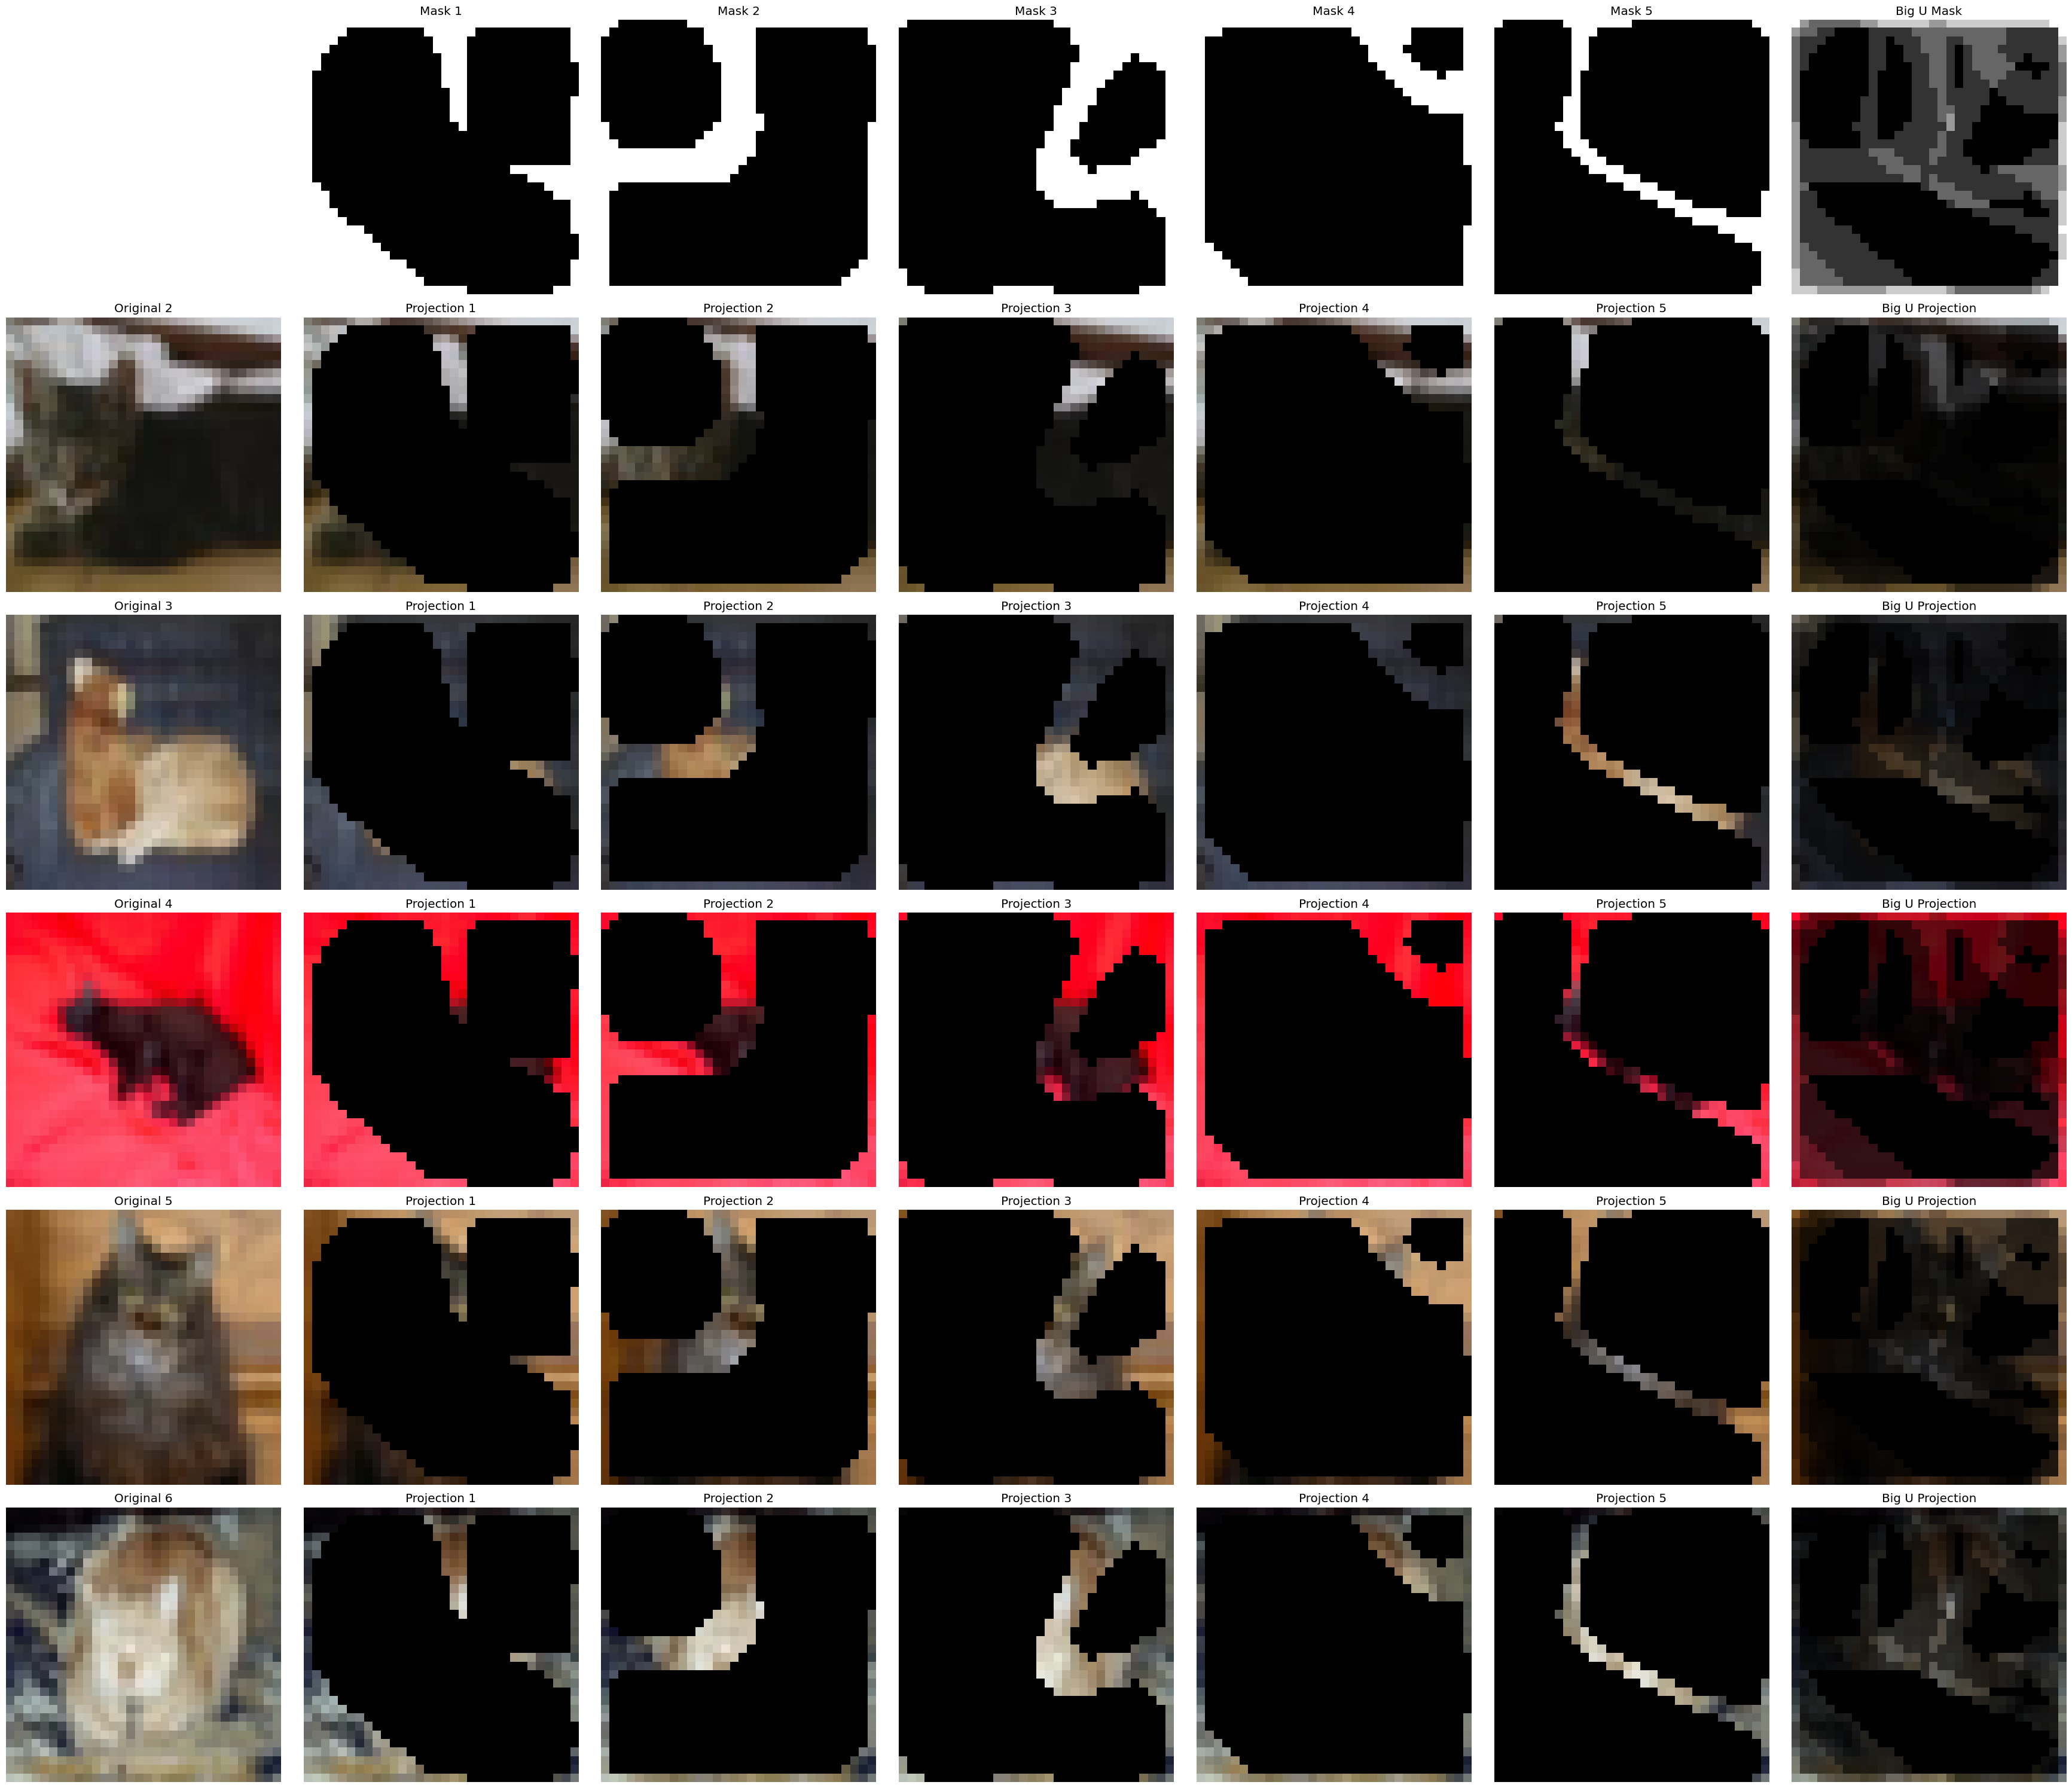

Average loss in the epoch: 0.03519420186057687
Epoch 51 of 100


Average loss in the epoch: 0.02626325748860836
Epoch 52 of 100


Average loss in the epoch: 0.022775385063141584
Epoch 53 of 100


Average loss in the epoch: 0.022221196442842484
Epoch 54 of 100


Average loss in the epoch: 0.024079123977571726
Epoch 55 of 100


...

Average loss in the epoch: 0.031512717716395855
Epoch 72 of 100


Average loss in the epoch: 0.026192378718405962
Epoch 73 of 100


Average loss in the epoch: 0.027327873278409243
Epoch 74 of 100


Average loss in the epoch: 0.02550370479002595
Epoch 75 of 100


Count:  500 PVal:  0.0010000000474974513
The show option has been depricated due to lack of utility


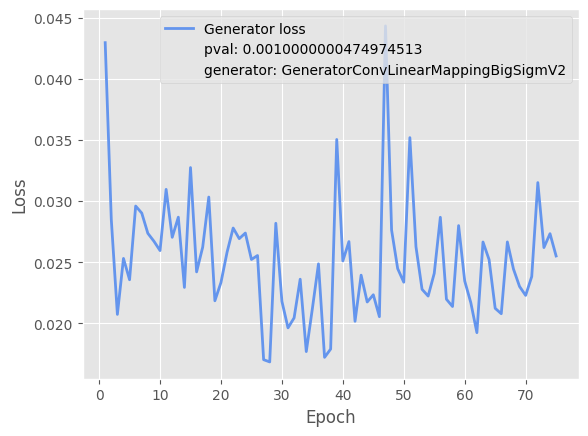

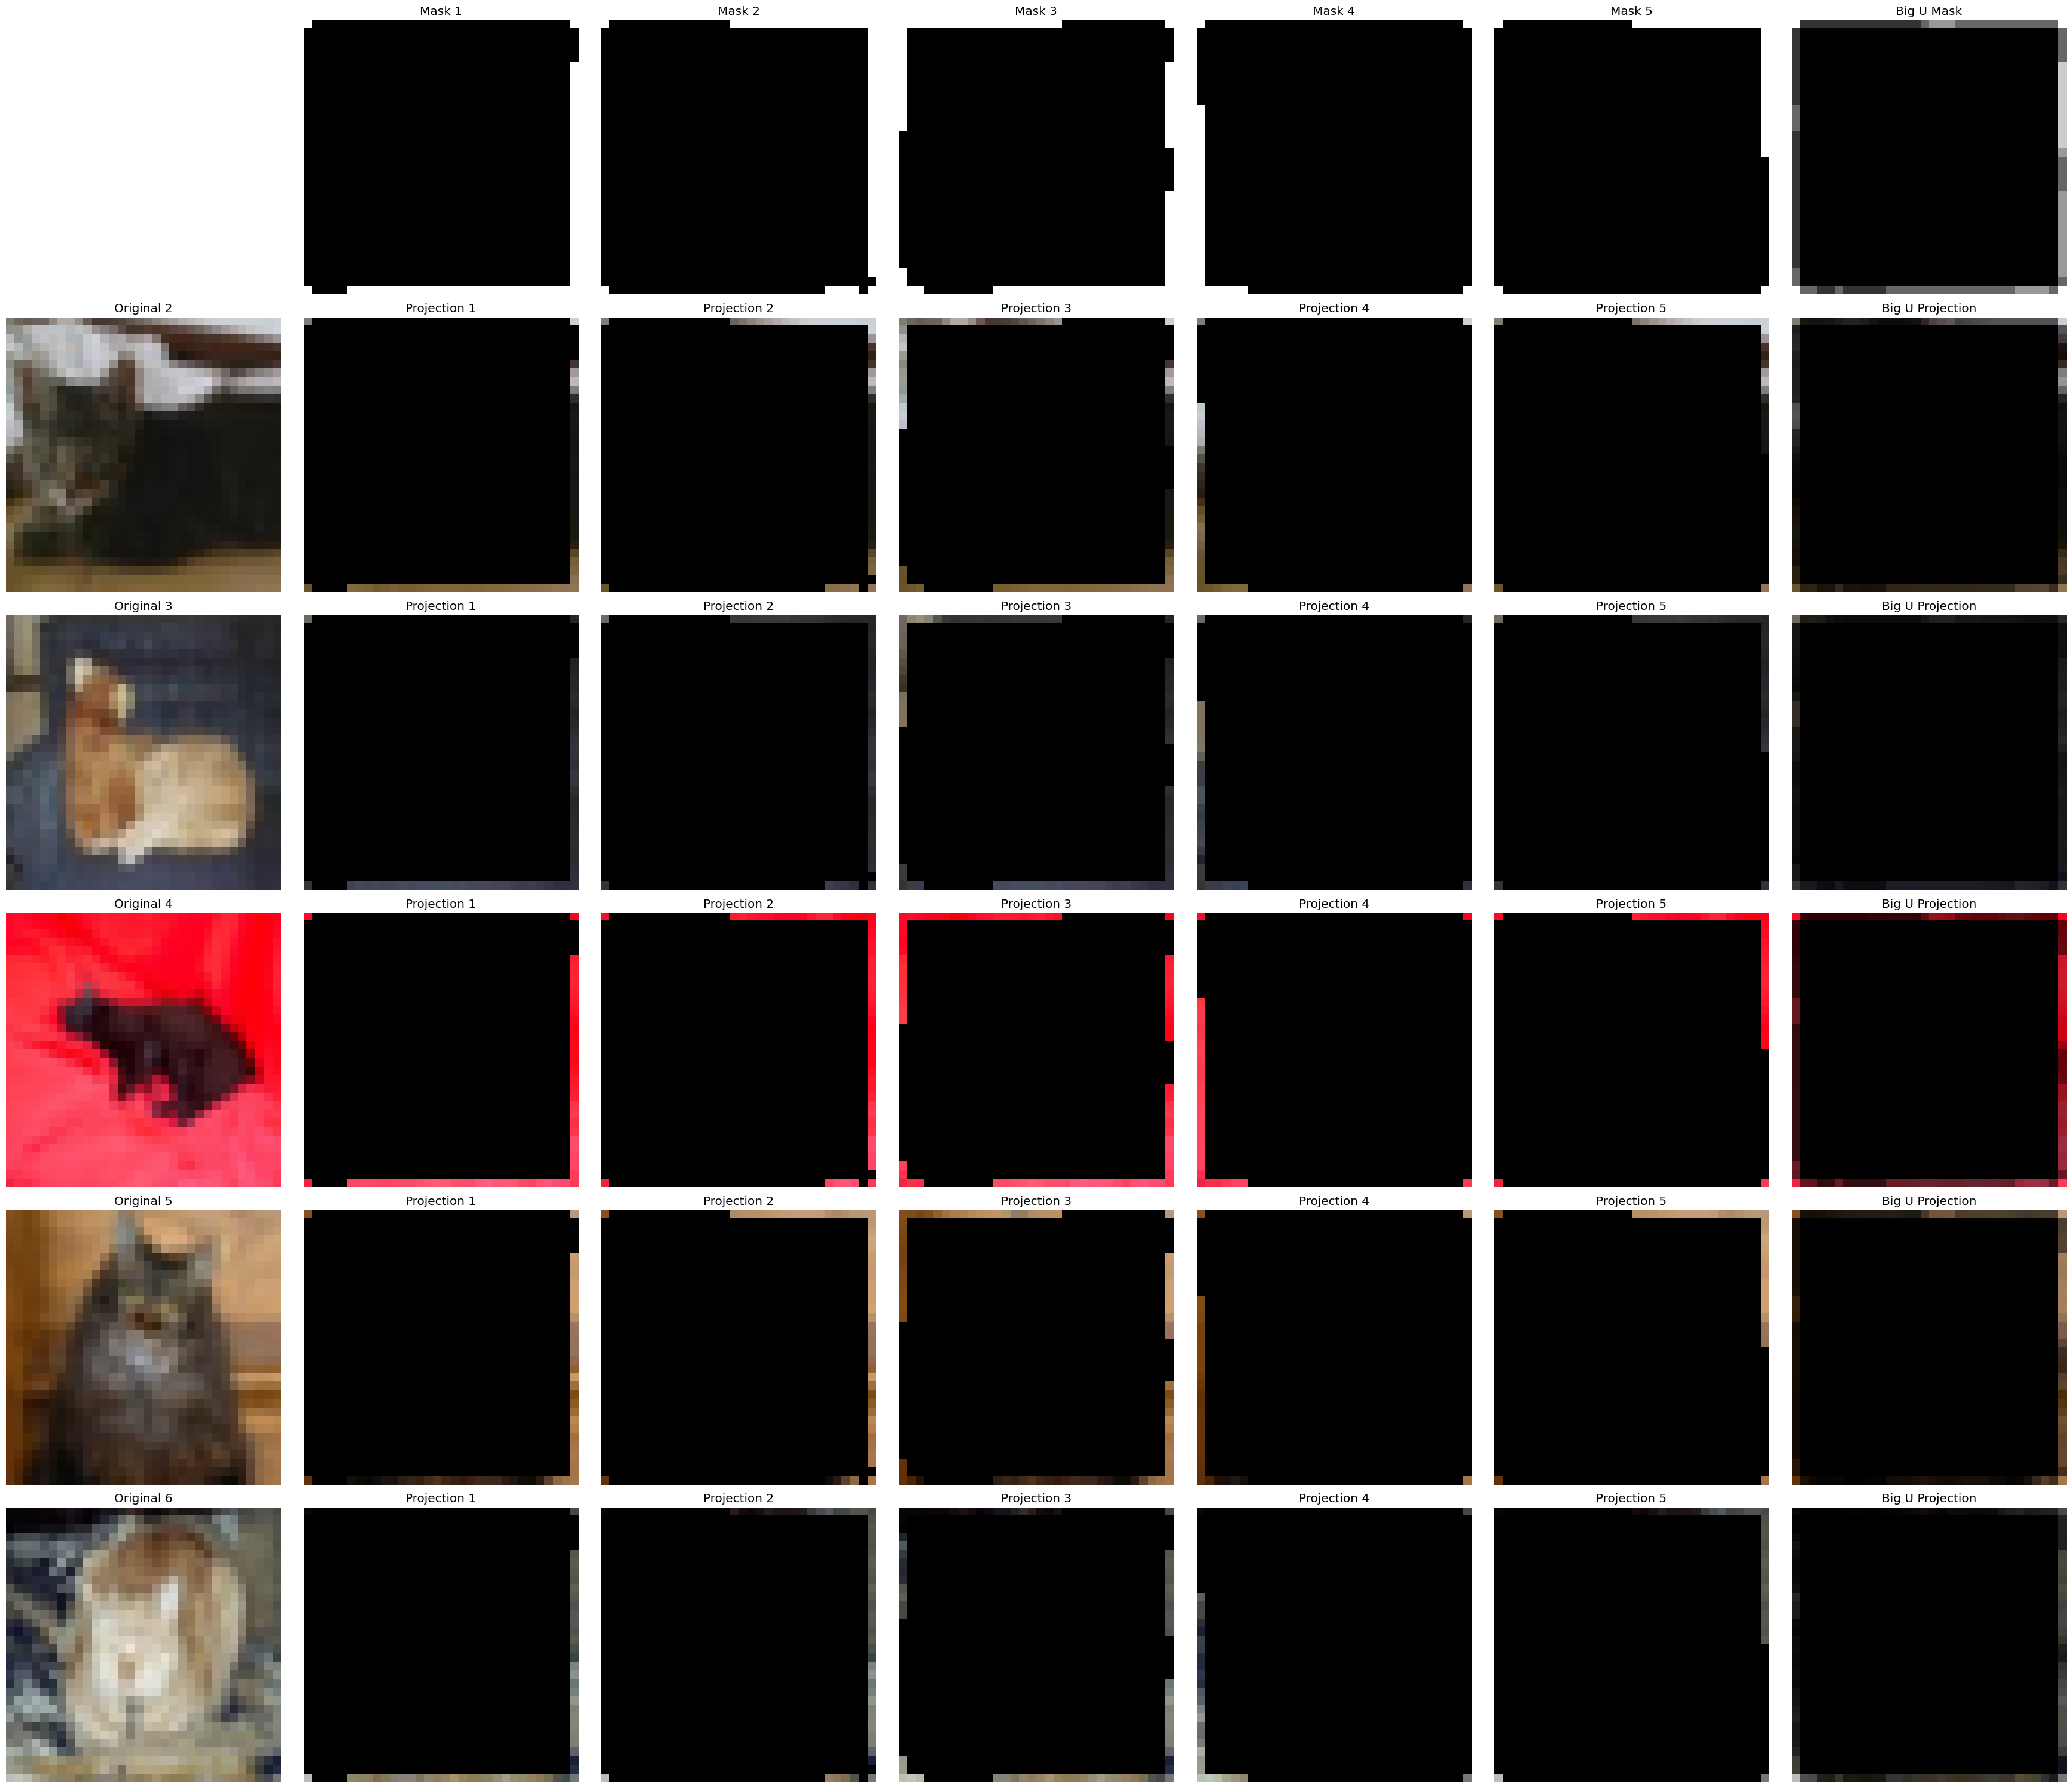

Average loss in the epoch: 0.024413414299488068
Epoch 76 of 100


Average loss in the epoch: 0.024175700265914202
Epoch 77 of 100


Average loss in the epoch: 0.023065393324941397
Epoch 78 of 100


Average loss in the epoch: 0.021867038682103157
Epoch 79 of 100


Average loss in the epoch: 0.026640992145985365
Epoch 80 of 100


...

Average loss in the epoch: 0.02906767651438713
Epoch 96 of 100


Average loss in the epoch: 0.028950776904821396
Epoch 97 of 100


Average loss in the epoch: 0.029513311572372913
Epoch 98 of 100


Average loss in the epoch: 0.033078860491514206
Epoch 99 of 100


Average loss in the epoch: 0.03200795268639922
Count:  500 PVal:  1.0
The show option has been depricated due to lack of utility


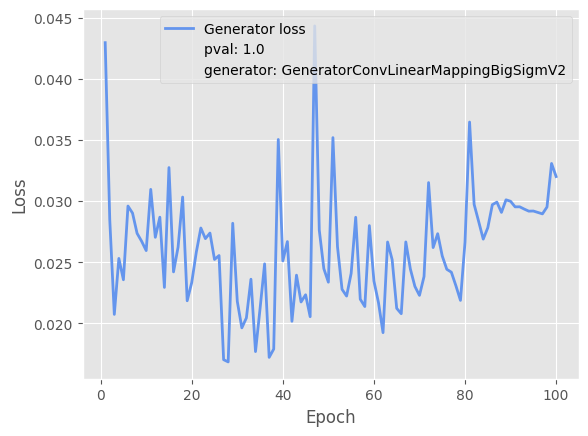

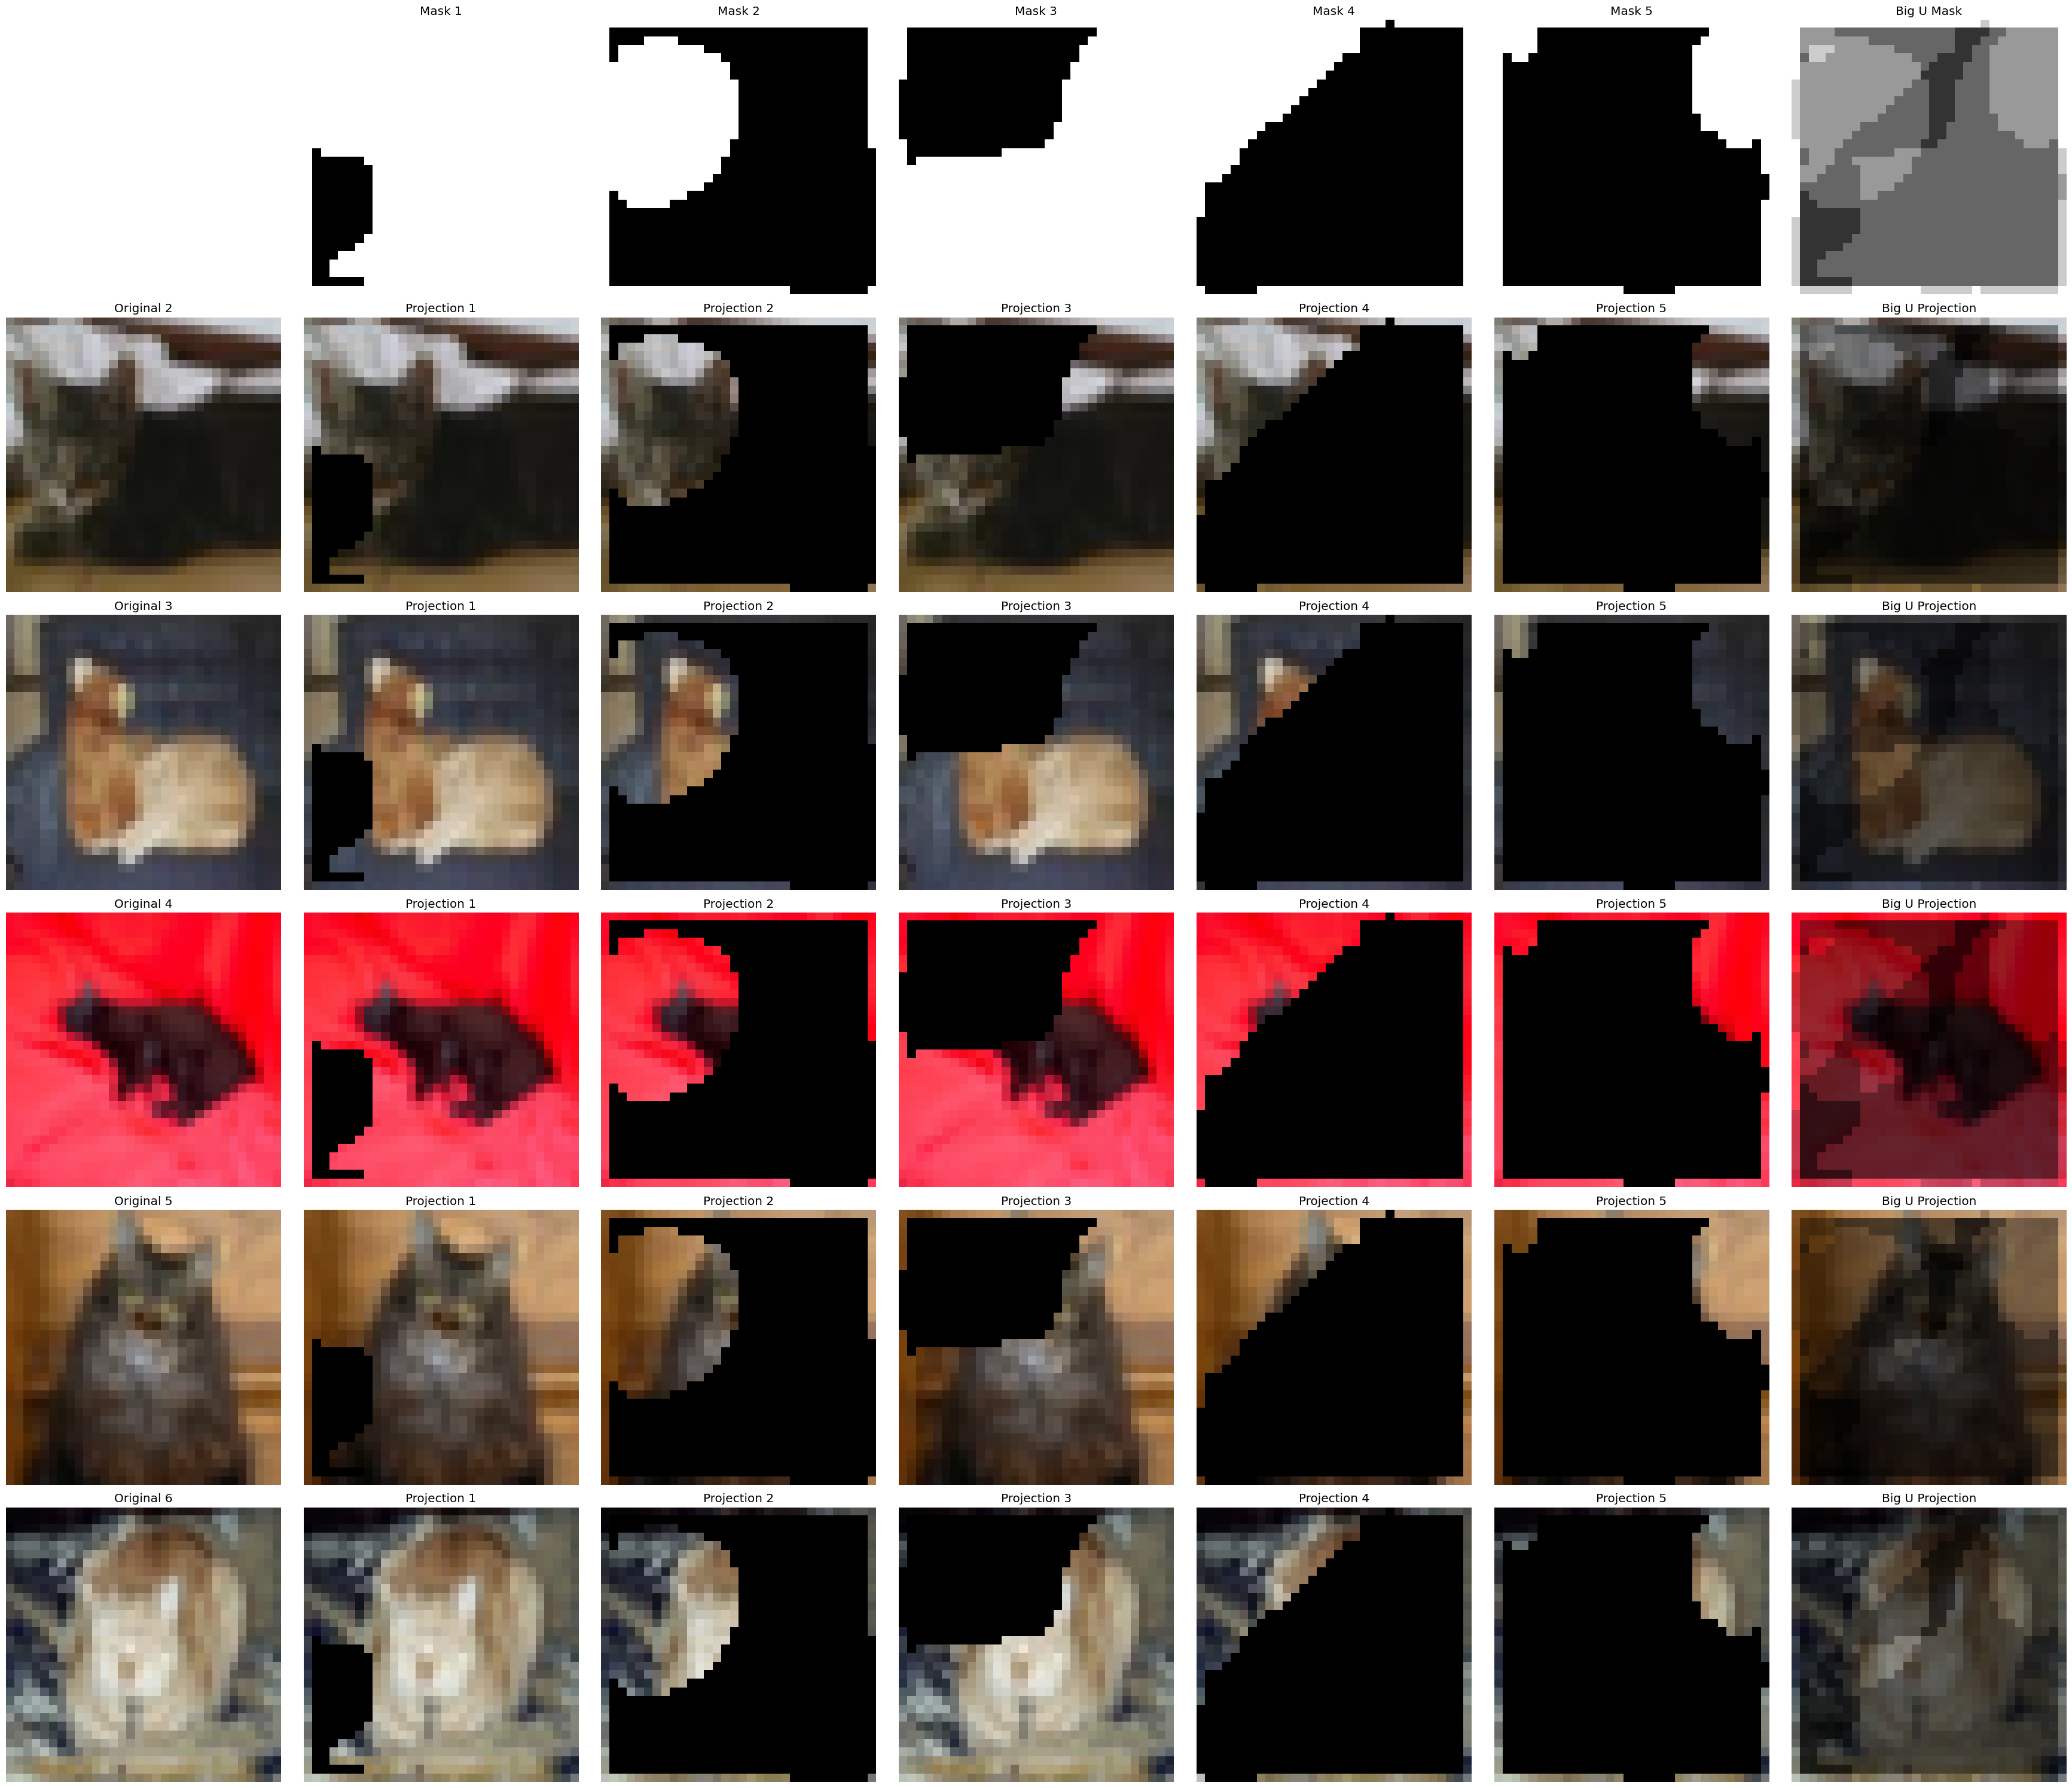

Count:  500 PVal:  1.0
The show option has been depricated due to lack of utility


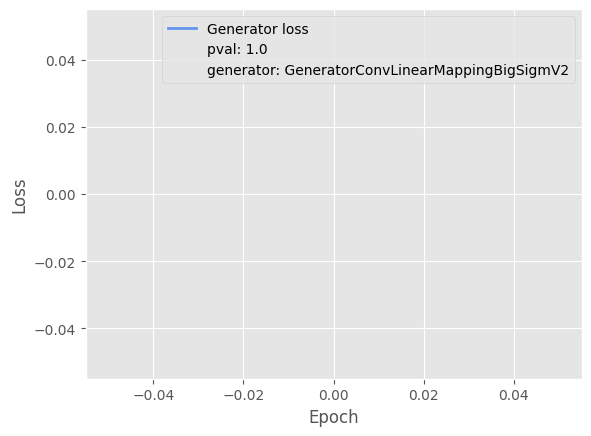

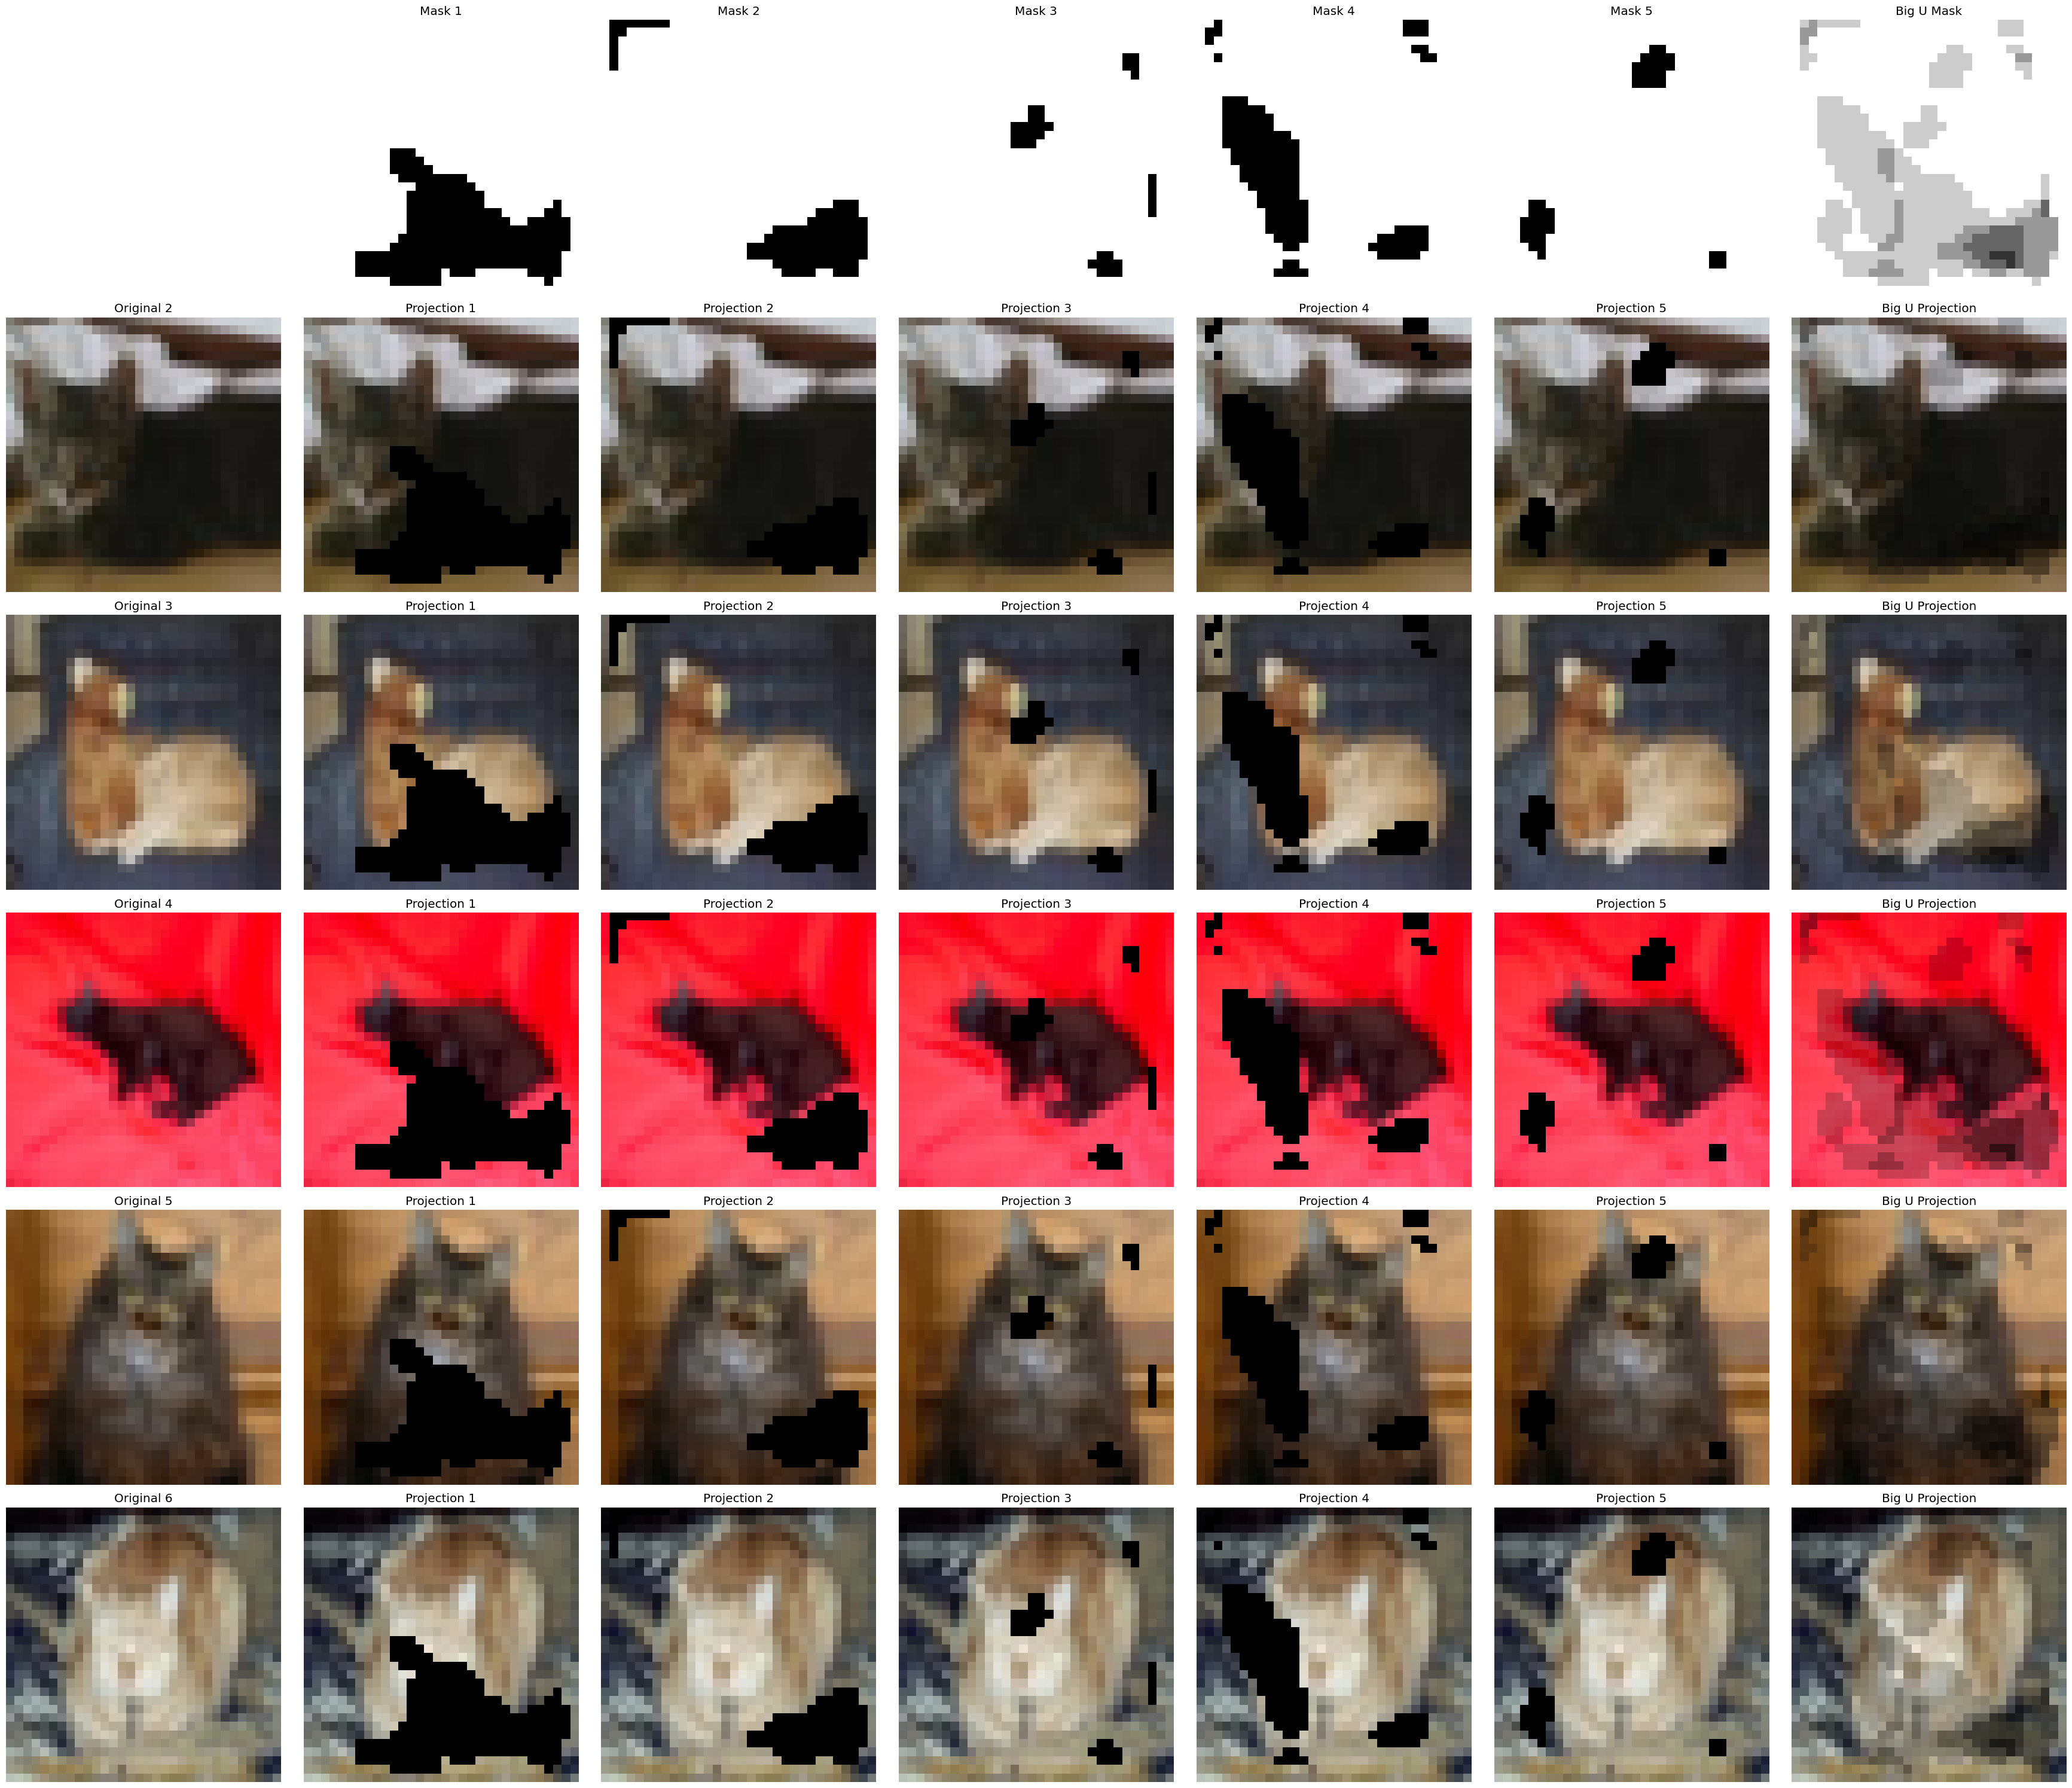

Epoch 0 of 100


Average loss in the epoch: 0.03511613514274359
Epoch 1 of 100


Average loss in the epoch: 0.02333739586174488
Epoch 2 of 100


Average loss in the epoch: 0.016531317261978984
Epoch 3 of 100


Average loss in the epoch: 0.027600247878581285
Epoch 4 of 100


...

Average loss in the epoch: 0.016508125234395266
Epoch 7 of 100


Average loss in the epoch: 0.016076506348326802
Epoch 8 of 100


Average loss in the epoch: 0.01227311510592699
Epoch 9 of 100


Average loss in the epoch: 0.015089868800714612
Epoch 10 of 100


KeyboardInterrupt: 

In [5]:
from src.models.generator.convolution.GeneratorConvLinearMappingBigSigmV3 import GeneratorConvLinearMappingBigSigmV3

hyperparameter_list = generate_hyperparams(n_iter=10, random_state=777)

for i in range(len(hyperparameter_list)):
    vmmd = VMMDConvLinearMappingRef(
        filename=f"conv_hypparam_tuning_0_test_{i}",
        weight_decay=hyperparameter_list[i]['weight_decay'],
        seed=hyperparameter_list[i]['seed'],
        momentum=hyperparameter_list[i]['momentum'],
        lr=0.1,
        epochs=1000,
        batch_size=hyperparameter_list[i]['batch_size'],
        path_to_directory="")
    noise_dim = torch.tensor([hyperparameter_list[i]['latent_size'], 1, 1])
    vmmd.fit(cats_dataset, ResNet18AutoEncoder(), GeneratorConvLinearMappingBigSigmV2(noise_dim))